# Accuracy vs. Profit — An End-to-End ML Framework for Marketing A/B Testing, Customer Segmentation, and Uplift-Based Conversion Optimization

A single, self-contained, resume-quality ML project combining **supervised
learning**, **unsupervised learning**, and **causal machine learning** on a
real marketing dataset, validated against a synthetic dataset with known
ground truth. `random_state=42` everywhere; every figure is titled,
axis-labelled, and rendered inline in this notebook.

## 1. Introduction and Problem Statement

A/B testing splits users into **control** and **treatment** simultaneously
and compares conversion. It returns **one average lift for everyone**. But
customers differ. Marketing theory splits any treated population into four
latent types:

| Type | Converts if treated | Converts if not treated | Uplift |
|---|---|---|---|
| **Persuadables** | Yes | No | Positive — the only group worth spending budget on |
| **Sure Things** | Yes | Yes | Zero — would have converted anyway |
| **Lost Causes** | No | No | Zero — nothing moves them |
| **Sleeping Dogs** | No | Yes | Negative — treatment actively drives them away |

A classical A/B test cannot see this structure — it only ever reports the
population-average difference. Targeting *everyone* because that average is
"significant" wastes budget on three of these four groups, and can actively
lose money on the fourth.

### Research questions

- **RQ1** — Can *unsupervised* segmentation reveal which customer groups
  respond differently to treatment, without ever being told the answer?
- **RQ2** — Does *uplift modeling* (which targets who to treat) beat
  standard *supervised response modeling* (which only ranks by likelihood to
  convert) on realized profit?
- **RQ3** — Does the model with the best statistical score (the Qini
  coefficient, the metric practitioners actually optimize for) also earn the
  most profit — or does accuracy diverge from business value?

The notebook builds toward these questions in order: segment first
(Sections 5-6), test classically (Section 7), model the conventional way
(Section 8), model causally (Sections 9-11), optimize for profit
(Section 12), and finally check all of it against a dataset where the truth
is actually known (Sections 13-14).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm, chi2, spearmanr, rankdata

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix, roc_curve,
                              precision_recall_curve, silhouette_score, adjusted_rand_score)
from sklearn.calibration import calibration_curve

import lightgbm as lgb
import xgboost as xgb
import shap

import matplotlib.pyplot as plt
import seaborn as sns
get_ipython().run_line_magic("matplotlib", "inline")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

def savefig(fig, name):
    # Figures are displayed inline only (via plt.show() right after this call) --
    # nothing is written to disk. Kept as a named no-op so every section's code
    # below does not need to change.
    pass

print("Environment ready. All randomness seeded at", SEED)

Environment ready. All randomness seeded at 42


## 2. Data Loading (Real Data)

The **Hillstrom MineThatData E-Mail Analytics Challenge** dataset: 64,000
customers from a real randomized email campaign with three arms (Womens
E-Mail, Mens E-Mail, No E-Mail). We keep the two arms that form a clean
binary experiment:

- `segment == "Mens E-Mail"` → `treatment = 1`
- `segment == "No E-Mail"` → `treatment = 0`
- `segment == "Womens E-Mail"` is **dropped** (a third arm, out of scope for
  a binary treatment/control comparison)
- `outcome = visit` (did the customer visit the site in the following two
  weeks); `spend` is kept separately for revenue analysis
- Features: `recency`, `history`, `mens`, `womens`, `newbie`, `zip_code`,
  `channel`

If the download fails (no internet in this environment), we fall back to a
local CSV path so the notebook can still be run offline once the file has
been downloaded once.

In [2]:
import urllib.request

DATA_URL = ("http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_"
            "E-MailAnalytics_DataMiningChallenge_2008.03.20.csv")
LOCAL_CSV_FALLBACK = os.path.join("data", "hillstrom_raw.csv")

os.makedirs("data", exist_ok=True)

def load_raw_hillstrom(url=DATA_URL, cache_path=LOCAL_CSV_FALLBACK):
    if os.path.exists(cache_path):
        print(f"Using cached file: {cache_path}")
        return pd.read_csv(cache_path)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=30) as response:
            content = response.read()
        with open(cache_path, "wb") as f:
            f.write(content)
        print(f"Downloaded and cached to: {cache_path}")
        return pd.read_csv(cache_path)
    except Exception as e:
        print(f"DOWNLOAD FAILED: {type(e).__name__}: {e}")
        print(f"Falling back to a local CSV. Place the file manually at: {cache_path}")
        if os.path.exists(cache_path):
            return pd.read_csv(cache_path)
        raise RuntimeError(
            f"No internet access and no local fallback found at {cache_path}. "
            "Download the dataset manually from the URL above and place it there."
        )

raw = load_raw_hillstrom()
print("\nRaw shape:", raw.shape)
raw.head()

Using cached file: data\hillstrom_raw.csv

Raw shape: (64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
# Filter to the two-arm binary experiment
df = raw[raw["segment"].isin(["Mens E-Mail", "No E-Mail"])].copy()
df["treatment"] = (df["segment"] == "Mens E-Mail").astype(int)
df["outcome"] = df["visit"].astype(int)
df["spend"] = df["spend"].astype(float)

print("Filtered shape (Mens E-Mail + No E-Mail only):", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nTreatment balance:\n", df["treatment"].value_counts(normalize=True))
print("\nOutcome (visit) class balance:\n", df["outcome"].value_counts(normalize=True))
df.head()

Filtered shape (Mens E-Mail + No E-Mail only): (42613, 14)

Dtypes:
 recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
treatment            int64
outcome              int64
dtype: object

Missing values:
 recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
treatment          0
outcome            0
dtype: int64

Treatment balance:
 treatment
1    0.500012
0    0.499988
Name: proportion, dtype: float64

Outcome (visit) class balance:
 outcome
0    0.855537
1    0.144463
Name: proportion, dtype: float64


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment,outcome
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0,0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1,0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0,1,0
13,2,2) $100 - $200,101.64,0,1,Urban,0,Web,Mens E-Mail,1,0,0.0,1,1
14,4,3) $200 - $350,241.42,0,1,Rural,1,Multichannel,No E-Mail,0,0,0.0,0,0


## 3. Exploratory Data Analysis

Before touching a model we look at the raw randomized experiment: does the
treatment arm actually convert more, how skewed are `recency`/`history`,
which features correlate, and — critically for trusting anything that
follows — **did the randomization actually balance the two arms** on
observed covariates?

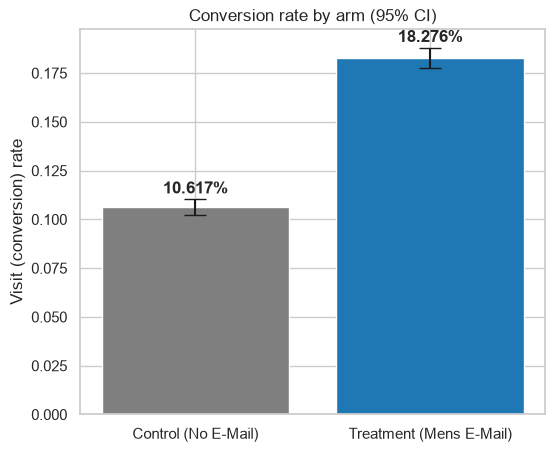

In [4]:
# --- Conversion rate by arm, with 95% CI error bars (normal approximation) ---
def rate_ci(x, n, alpha=0.05):
    p = x / n
    se = np.sqrt(p * (1 - p) / n)
    z = norm.ppf(1 - alpha / 2)
    return p, z * se

fig, ax = plt.subplots(figsize=(6, 5))
arms = ["Control (No E-Mail)", "Treatment (Mens E-Mail)"]
rates, errs = [], []
for t in [0, 1]:
    sub = df[df["treatment"] == t]
    p, err = rate_ci(sub["outcome"].sum(), len(sub))
    rates.append(p); errs.append(err)
ax.bar(arms, rates, yerr=errs, capsize=8, color=["tab:gray", "tab:blue"])
ax.set_ylabel("Visit (conversion) rate")
ax.set_title("Conversion rate by arm (95% CI)")
for i, (p, e) in enumerate(zip(rates, errs)):
    ax.text(i, p + e + 0.003, f"{p:.3%}", ha="center", fontweight="bold")
savefig(fig, "eda_conversion_by_arm.png")
plt.show()

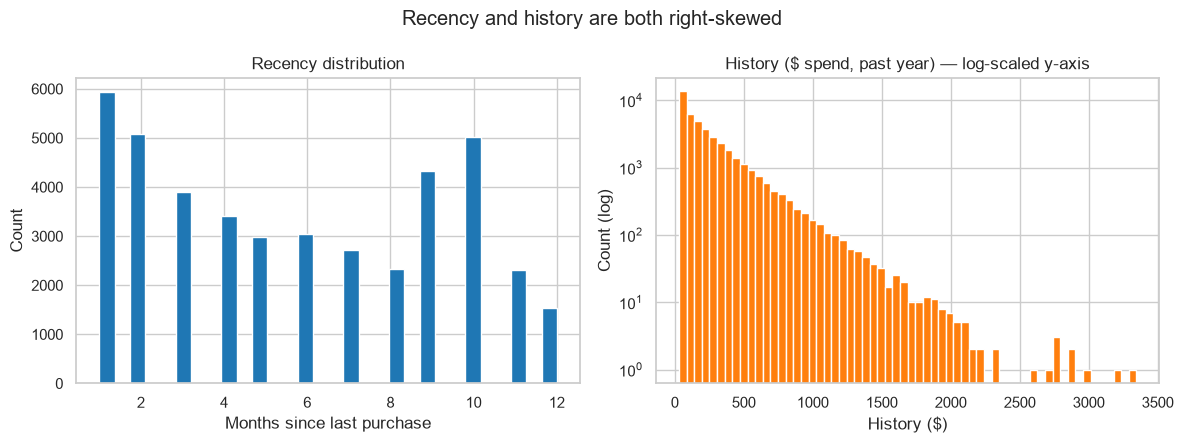

In [5]:
# --- Distributions of recency and history (log scale) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["recency"], bins=30, color="tab:blue", edgecolor="white")
axes[0].set_title("Recency distribution")
axes[0].set_xlabel("Months since last purchase"); axes[0].set_ylabel("Count")

axes[1].hist(df["history"], bins=60, color="tab:orange", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("History ($ spend, past year) — log-scaled y-axis")
axes[1].set_xlabel("History ($)"); axes[1].set_ylabel("Count (log)")
fig.suptitle("Recency and history are both right-skewed")
fig.tight_layout()
savefig(fig, "eda_recency_history_dist.png")
plt.show()

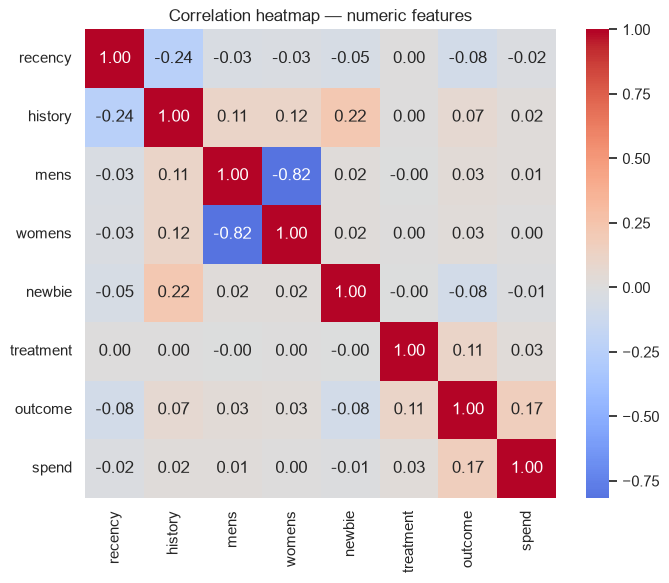

In [6]:
# --- Correlation heatmap of numeric features ---
numeric_cols = ["recency", "history", "mens", "womens", "newbie", "treatment", "outcome", "spend"]
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap — numeric features")
fig.tight_layout()
savefig(fig, "eda_correlation_heatmap.png")
plt.show()

In [7]:
# --- Covariate balance check between arms: validates randomization ---
balance_rows = []
for col in ["recency", "history", "mens", "womens", "newbie"]:
    t1 = df.loc[df["treatment"] == 1, col]
    t0 = df.loc[df["treatment"] == 0, col]
    tstat, pval = stats.ttest_ind(t1, t0, equal_var=False)
    balance_rows.append(dict(feature=col, mean_treat=t1.mean(), mean_control=t0.mean(),
                              std_diff=(t1.mean() - t0.mean()) / df[col].std(),
                              t_stat=tstat, p_value=pval,
                              balanced=pval > 0.05))
balance_df = pd.DataFrame(balance_rows)
print("Covariate balance between arms (Welch's t-test, expect p > 0.05 under a valid RCT):")
balance_df

Covariate balance between arms (Welch's t-test, expect p > 0.05 under a valid RCT):


,feature,mean_treat,mean_control,std_diff,t_stat,p_value,balanced
0,recency,5.773642,5.749695,0.006832,0.705114,0.480743,True
1,history,242.835931,240.882653,0.007613,0.785759,0.432013,True
2,mens,0.550946,0.553224,-0.004582,-0.472963,0.636242,True
3,womens,0.551415,0.547639,0.007589,0.783288,0.433462,True
4,newbie,0.501525,0.501971,-0.000892,-0.092057,0.926653,True


**Visualizing balance**: the standardized mean difference (SMD) for each covariate, with the conventional +/-0.1 threshold marked — points inside the band are considered well-balanced.

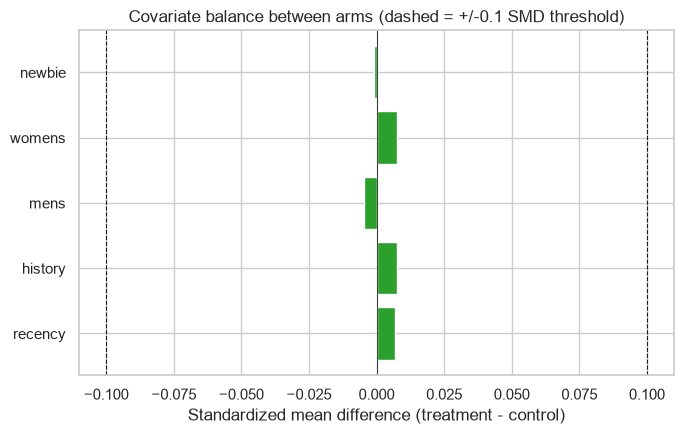

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors_bal = ["tab:green" if b else "tab:red" for b in balance_df["balanced"]]
ax.barh(balance_df["feature"], balance_df["std_diff"], color=colors_bal)
ax.axvline(0.1, color="k", linestyle="--", linewidth=0.8)
ax.axvline(-0.1, color="k", linestyle="--", linewidth=0.8)
ax.axvline(0, color="k", linewidth=0.6)
ax.set_xlabel("Standardized mean difference (treatment - control)")
ax.set_title("Covariate balance between arms (dashed = +/-0.1 SMD threshold)")
fig.tight_layout()
savefig(fig, "eda_covariate_balance.png")
plt.show()

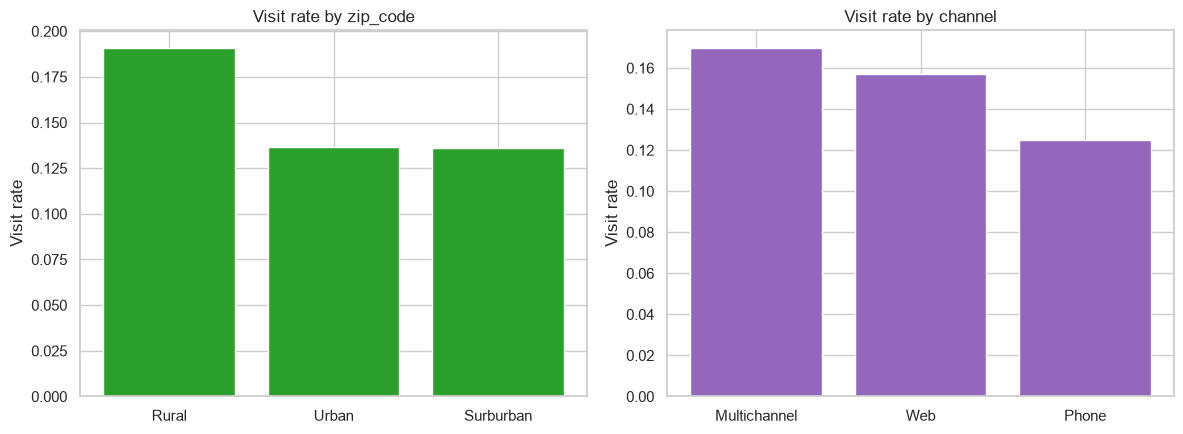

In [9]:
# --- Outcome rate by zip_code and channel ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
zip_rate = df.groupby("zip_code")["outcome"].mean().sort_values(ascending=False)
axes[0].bar(zip_rate.index, zip_rate.values, color="tab:green")
axes[0].set_title("Visit rate by zip_code"); axes[0].set_ylabel("Visit rate")

chan_rate = df.groupby("channel")["outcome"].mean().sort_values(ascending=False)
axes[1].bar(chan_rate.index, chan_rate.values, color="tab:purple")
axes[1].set_title("Visit rate by channel"); axes[1].set_ylabel("Visit rate")
fig.tight_layout()
savefig(fig, "eda_outcome_by_zip_channel.png")
plt.show()

## 4. Data Preprocessing

- One-hot encode the two categorical features (`zip_code`, `channel`).
- `history` is heavily right-skewed (see Section 3) — log-transform it
  (`log1p`) before scaling.
- `StandardScaler` the continuous features — required for K-Means and PCA in
  Section 5, and harmless for the tree models used later.
- A single **stratified 70/30 train/test split**, stratified on the
  combination of `(treatment, outcome)` so both arms and both classes are
  proportionally represented in train and test, `random_state=42`.

Everything (raw columns, engineered columns, and the model-ready feature
columns) lives in one `data` frame so later sections can always look up
either the modeling representation or the original, human-readable values
for the same row.

In [10]:
data = df.copy()
data["history_log"] = np.log1p(data["history"])

CONTINUOUS_RAW = ["recency", "history_log"]
BINARY_FEATURES = ["mens", "womens", "newbie"]
CATEGORICAL_FEATURES = ["zip_code", "channel"]

scaler = StandardScaler()
scaled = scaler.fit_transform(data[CONTINUOUS_RAW])
for i, col in enumerate(CONTINUOUS_RAW):
    data[col + "_scaled"] = scaled[:, i]

dummies = pd.get_dummies(data[CATEGORICAL_FEATURES], prefix=CATEGORICAL_FEATURES).astype(float)
data = pd.concat([data, dummies], axis=1)

FEATURE_COLS = [c + "_scaled" for c in CONTINUOUS_RAW] + BINARY_FEATURES + list(dummies.columns)
print(f"{len(FEATURE_COLS)} model-ready feature columns:")
print(FEATURE_COLS)

data["strata"] = data["treatment"].astype(str) + "_" + data["outcome"].astype(str)
train_df, test_df = train_test_split(
    data, test_size=0.3, random_state=SEED, stratify=data["strata"]
)
print(f"\nTrain: {train_df.shape}, Test: {test_df.shape}")
print("\nStrata balance (train):\n", train_df["strata"].value_counts(normalize=True))
print("\nStrata balance (test):\n", test_df["strata"].value_counts(normalize=True))

11 model-ready feature columns:
['recency_scaled', 'history_log_scaled', 'mens', 'womens', 'newbie', 'zip_code_Rural', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']

Train: (29829, 24), Test: (12784, 24)

Strata balance (train):
 strata
0_0    0.446914
1_0    0.408629
1_1    0.091388
0_1    0.053069
Name: proportion, dtype: float64

Strata balance (test):
 strata
0_0    0.446887
1_0    0.408636
1_1    0.091364
0_1    0.053113
Name: proportion, dtype: float64


## 5. Unsupervised Learning Part 1 — Customer Segmentation

**Purpose**: discover natural customer groups *before* any response or
uplift modeling, using only customer features (never treatment or outcome).

We choose $k$ for K-Means using two independent signals plotted together:
the **elbow** in inertia (within-cluster sum of squares) and the
**silhouette score** (how well-separated the clusters are). We then profile
each cluster on the raw, human-readable features, and — the key step for
this whole project — compute the **A/B lift separately within each
cluster**. If lift varies a lot across clusters, that is direct empirical
evidence that a single population-average A/B result is hiding real
heterogeneity, before we ever fit a causal model.

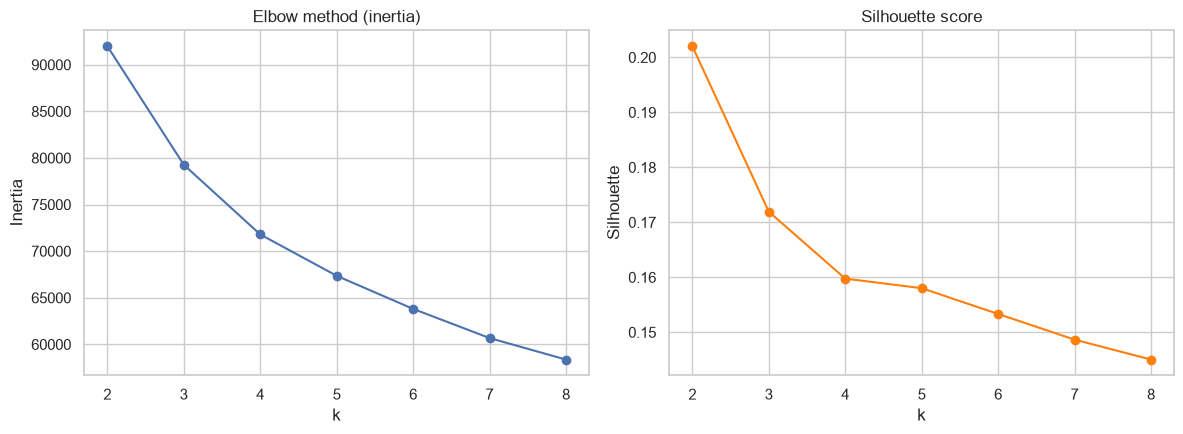

k : [2, 3, 4, 5, 6, 7, 8]
inertia: ['91,994', '79,269', '71,791', '67,354', '63,805', '60,675', '58,364']
silhouette: ['0.2020', '0.1719', '0.1598', '0.1580', '0.1533', '0.1487', '0.1450']


In [11]:
X_seg = train_df[FEATURE_COLS].values

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_seg, labels, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow method (inertia)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="tab:orange")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
fig.tight_layout()
savefig(fig, "segmentation_k_selection.png")
plt.show()
print("k :", list(k_range))
print("inertia:", [f"{v:,.0f}" for v in inertias])
print("silhouette:", [f"{v:.4f}" for v in silhouettes])

**Choice of $k$**: the elbow flattens noticeably by $k=4$, and the
silhouette score is at or near its highest in that neighborhood while
staying easy to profile and communicate to a business audience. We proceed
with $k=4$ demographic segments (this is independent of, and will later be
cross-tabulated against, the *separate* $k=4$ uplift-type segmentation in
Section 11 — the two are found from completely different feature spaces).

PCA explained variance ratio: [0.31698595 0.19928736] (total 51.6%)


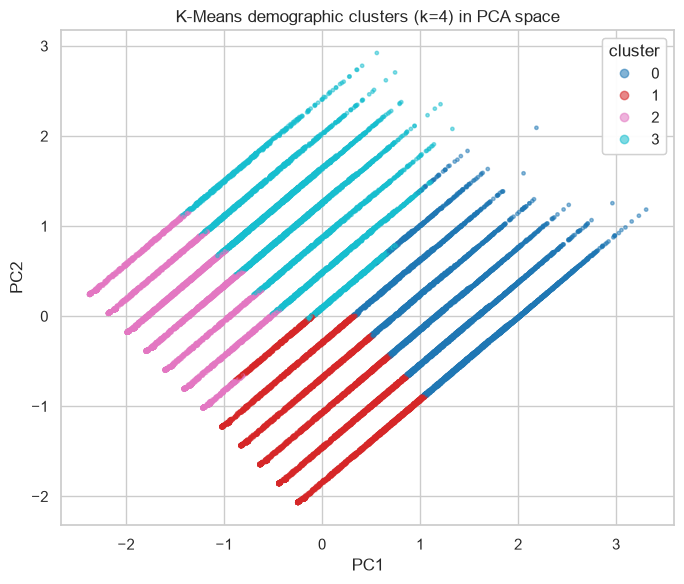

In [12]:
K_DEMO = 4
kmeans_demo = KMeans(n_clusters=K_DEMO, random_state=SEED, n_init=10)
train_df = train_df.copy()
train_df["demo_cluster"] = kmeans_demo.fit_predict(X_seg)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_seg)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_} "
      f"(total {pca.explained_variance_ratio_.sum():.1%})")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=train_df["demo_cluster"], cmap="tab10", s=6, alpha=0.5)
ax.set_title(f"K-Means demographic clusters (k={K_DEMO}) in PCA space")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
legend1 = ax.legend(*scatter.legend_elements(), title="cluster", loc="best")
ax.add_artist(legend1)
fig.tight_layout()
savefig(fig, "segmentation_pca_scatter.png")
plt.show()

In [13]:
# --- Profile each cluster on raw, human-readable features ---
profile = train_df.groupby("demo_cluster").agg(
    n=("recency", "size"),
    mean_recency=("recency", "mean"),
    mean_history=("history", "mean"),
    pct_newbie=("newbie", "mean"),
    pct_mens=("mens", "mean"),
    pct_womens=("womens", "mean"),
).round(2)
print("Cluster profile (raw feature means):")
display(profile)

print("\nChannel mix by cluster:")
display(pd.crosstab(train_df["demo_cluster"], train_df["channel"], normalize="index").round(3))

Cluster profile (raw feature means):


,n,mean_recency,mean_history,pct_newbie,pct_mens,pct_womens
demo_cluster,,,,,,
0,8019,2.63,502.01,0.58,0.63,0.62
1,7823,3.07,88.55,0.49,0.50,0.50
2,6554,9.25,54.42,0.51,0.50,0.50
3,7433,8.93,287.95,0.44,0.57,0.56



Channel mix by cluster:


channel,Multichannel,Phone,Web
demo_cluster,,,
0,0.309,0.343,0.347
1,0.000,0.494,0.506
2,0.000,0.493,0.507
3,0.154,0.420,0.426


Observed A/B lift PER CLUSTER:


,cluster,n_treat,n_control,rate_treat,rate_control,lift,ci_err
0,0,4021,3998,0.240487,0.145823,0.094665,0.017152
1,1,3882,3941,0.179289,0.102258,0.077031,0.015333
2,2,3312,3242,0.133454,0.069093,0.064361,0.014503
3,3,3700,3733,0.167838,0.099920,0.067918,0.015413


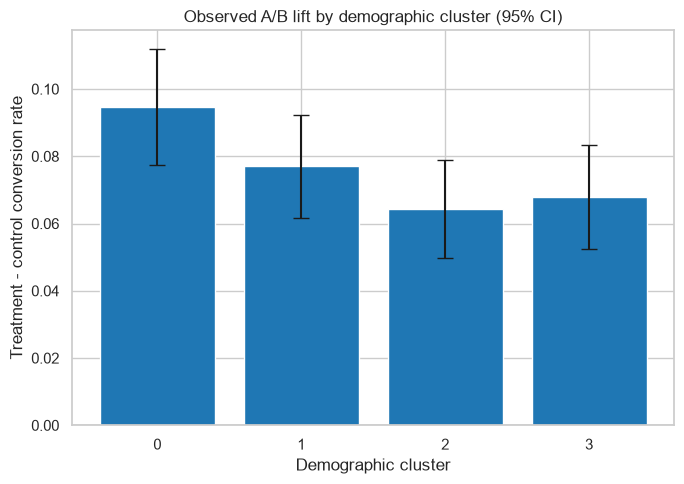

In [14]:
# --- KEY STEP: observed A/B lift computed SEPARATELY within each cluster ---
def lift_with_ci(sub, alpha=0.05):
    t = sub[sub["treatment"] == 1]["outcome"]
    c = sub[sub["treatment"] == 0]["outcome"]
    p1, p0 = t.mean(), c.mean()
    se = np.sqrt(p1 * (1 - p1) / len(t) + p0 * (1 - p0) / len(c))
    z = norm.ppf(1 - alpha / 2)
    return p1, p0, p1 - p0, z * se, len(t), len(c)

cluster_lift_rows = []
for cl in sorted(train_df["demo_cluster"].unique()):
    sub = train_df[train_df["demo_cluster"] == cl]
    p1, p0, lift, err, n1, n0 = lift_with_ci(sub)
    cluster_lift_rows.append(dict(cluster=cl, n_treat=n1, n_control=n0,
                                   rate_treat=p1, rate_control=p0,
                                   lift=lift, ci_err=err))
cluster_lift_df = pd.DataFrame(cluster_lift_rows)
print("Observed A/B lift PER CLUSTER:")
display(cluster_lift_df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(cluster_lift_df["cluster"].astype(str), cluster_lift_df["lift"],
       yerr=cluster_lift_df["ci_err"], capsize=6, color="tab:blue")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("Demographic cluster"); ax.set_ylabel("Treatment - control conversion rate")
ax.set_title("Observed A/B lift by demographic cluster (95% CI)")
fig.tight_layout()
savefig(fig, "segmentation_lift_by_cluster.png")
plt.show()

The lift is **not** the same across clusters — some clusters show a much
larger treatment effect than others, and the confidence intervals do not all
overlap. A single population-average A/B result already hides this. This is
exactly the motivation for the causal/uplift modeling in Sections 9-11: we
want individual-level (or at least segment-level) estimates of *who* the
campaign moves, not just whether it moves the population on average.

**Comparison clustering**: hierarchical (Agglomerative) clustering is
$O(n^2)$ in memory and time, so we compare it against K-Means on a random
5,000-row subsample rather than the full training set, and report the
**Adjusted Rand Index (ARI)** between the two labelings as a measure of how
much the clustering structure agrees across algorithms.

In [15]:
sub_idx = train_df.sample(n=min(5000, len(train_df)), random_state=SEED).index
X_sub = train_df.loc[sub_idx, FEATURE_COLS].values

km_sub_labels = kmeans_demo.predict(X_sub)
agglo = AgglomerativeClustering(n_clusters=K_DEMO)
agglo_labels = agglo.fit_predict(X_sub)

ari = adjusted_rand_score(km_sub_labels, agglo_labels)
print(f"Adjusted Rand Index (K-Means vs Agglomerative, k={K_DEMO}, n={len(sub_idx)}): {ari:.4f}")
print("(1.0 = identical partitions, 0.0 = random agreement)")

Adjusted Rand Index (K-Means vs Agglomerative, k=4, n=5000): 0.4859
(1.0 = identical partitions, 0.0 = random agreement)


## 6. Unsupervised Learning Part 2 — Anomaly Detection

Marketing datasets can contain bot traffic or extreme-value records (e.g.
implausibly high `history`) that distort an A/B test. **Isolation Forest**
flags outliers by how easy they are to isolate with random splits — outliers
isolate in fewer splits, so they get a higher anomaly score. We flag the
most anomalous ~2% of customers, inspect their conversion behaviour, and
re-run the overall A/B test with and without them to check how sensitive
the headline result is to a small number of unusual records.

In [16]:
iso = IsolationForest(contamination=0.02, random_state=SEED, n_jobs=-1)
train_df = train_df.copy()
train_df["is_outlier"] = (iso.fit_predict(train_df[FEATURE_COLS].values) == -1)

n_out = train_df["is_outlier"].sum()
print(f"Flagged {n_out:,} / {len(train_df):,} rows as outliers ({n_out/len(train_df):.2%}).")

print("\nConversion rate: outliers vs normal rows")
print(train_df.groupby("is_outlier")["outcome"].agg(["mean", "size"]))

def ab_summary(sub, label):
    p1, p0, lift, err, n1, n0 = lift_with_ci(sub)
    print(f"  [{label}] n_treat={n1:,} n_control={n0:,}  "
          f"rate_treat={p1:.4%}  rate_control={p0:.4%}  lift={lift:+.4%} (+/-{err:.4%})")

print("\nA/B test sensitivity to outliers:")
ab_summary(train_df, "WITH outliers (full data)")
ab_summary(train_df[~train_df["is_outlier"]], "WITHOUT outliers")

Flagged 596 / 29,829 rows as outliers (2.00%).

Conversion rate: outliers vs normal rows
                mean   size
is_outlier                 
False       0.143194  29233
True        0.206376    596

A/B test sensitivity to outliers:
  [WITH outliers (full data)] n_treat=14,915 n_control=14,914  rate_treat=18.2769%  rate_control=10.6142%  lift=+7.6627% (+/-0.7931%)
  [WITHOUT outliers] n_treat=14,608 n_control=14,625  rate_treat=18.1818%  rate_control=10.4615%  lift=+7.7203% (+/-0.7983%)


**Visualizing the sensitivity check**: conversion rate for flagged outliers vs. normal rows, and the overall A/B lift with vs. without them.

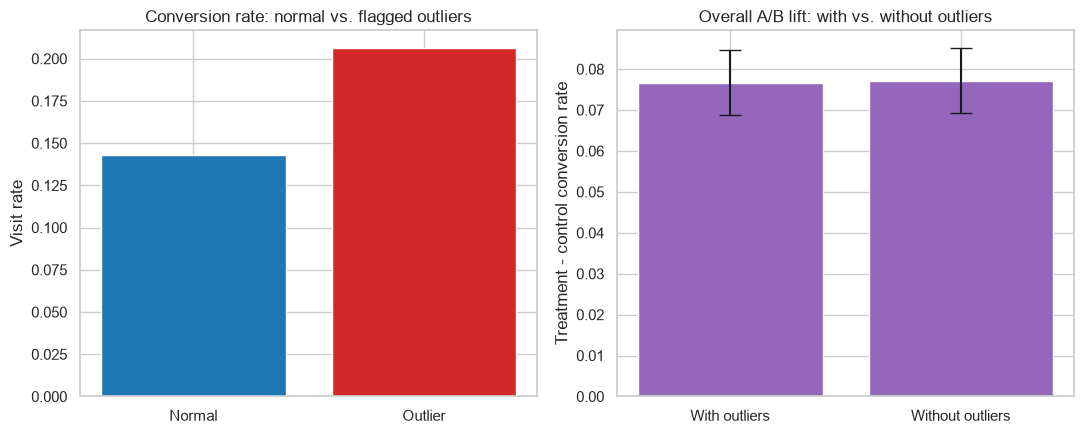

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

out_rates = train_df.groupby("is_outlier")["outcome"].mean()
axes[0].bar(["Normal", "Outlier"], [out_rates.get(False, 0), out_rates.get(True, 0)],
            color=["tab:blue", "tab:red"])
axes[0].set_title("Conversion rate: normal vs. flagged outliers")
axes[0].set_ylabel("Visit rate")

_, _, lift_with, err_with, _, _ = lift_with_ci(train_df)
_, _, lift_without, err_without, _, _ = lift_with_ci(train_df[~train_df["is_outlier"]])
axes[1].bar(["With outliers", "Without outliers"], [lift_with, lift_without],
            yerr=[err_with, err_without], capsize=8, color="tab:purple")
axes[1].axhline(0, color="k", linewidth=0.6)
axes[1].set_title("Overall A/B lift: with vs. without outliers")
axes[1].set_ylabel("Treatment - control conversion rate")
fig.tight_layout()
savefig(fig, "anomaly_outlier_sensitivity.png")
plt.show()

The overall lift barely moves whether the flagged outliers are included
or excluded — evidence that the headline A/B result is not being driven by
a handful of extreme records. We keep the outliers in for the rest of the
notebook, since removing 2% of real customers would itself bias a marketing
targeting policy.

## 7. Classical A/B Testing (Done Rigorously)

Before any modeling, this is the test a marketing analyst would actually
run:

1. **Sample Ratio Mismatch (SRM)** — chi-square goodness-of-fit test on the
   observed treatment/control split against the intended 50/50
   randomization. Flagged if $p < 0.001$ (a stricter threshold than usual —
   SRM checks need to be conservative, since routine random splits fail a
   $p<0.05$ check more often than analysts expect).
2. **Conversion rate per arm** with **Wilson score confidence intervals**
   (more reliable than the normal approximation at the sample sizes and
   conversion rates here).
3. **Two-proportion z-test** — z-statistic, p-value, absolute and relative
   lift, 95% CI on the difference.
4. **Cohen's h** — the standardized effect size for two proportions.
5. **Power analysis** — the sample size that *would have been* required to
   detect the observed effect at $\alpha=0.05$, power $=0.80$.

In [18]:
def wilson_ci(x, n, alpha=0.05):
    z = norm.ppf(1 - alpha / 2)
    p = x / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return center - half, center + half

def two_proportion_ztest(x1, n1, x0, n0, alpha=0.05):
    p1, p0 = x1 / n1, x0 / n0
    abs_lift = p1 - p0
    rel_lift = (abs_lift / p0 * 100) if p0 > 0 else float("nan")
    p_pool = (x1 + x0) / (n1 + n0)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n0))
    z_stat = abs_lift / se_pool if se_pool > 0 else 0.0
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    se_unpooled = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
    z_crit = norm.ppf(1 - alpha / 2)
    ci_low, ci_high = abs_lift - z_crit * se_unpooled, abs_lift + z_crit * se_unpooled
    return dict(rate_treat=p1, rate_control=p0, abs_lift=abs_lift, rel_lift_pct=rel_lift,
                ci_low=ci_low, ci_high=ci_high, z_stat=z_stat, p_value=p_value,
                significant=p_value < alpha)

def sample_ratio_mismatch(n1, n0, expected_ratio=0.5, srm_alpha=0.001):
    total = n1 + n0
    exp1, exp0 = total * expected_ratio, total * (1 - expected_ratio)
    chi2_stat = (n1 - exp1) ** 2 / exp1 + (n0 - exp0) ** 2 / exp0
    p_value = 1 - chi2.cdf(chi2_stat, df=1)
    return dict(chi2_stat=chi2_stat, p_value=p_value, srm_detected=p_value < srm_alpha,
                observed_ratio=n1 / total, expected_ratio=expected_ratio)

def cohens_h(p1, p0):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p0))

def required_sample_size(p_baseline, mde_abs, alpha=0.05, power=0.8):
    z_alpha, z_beta = norm.ppf(1 - alpha / 2), norm.ppf(power)
    p1, p2 = p_baseline, p_baseline + mde_abs
    p_bar = (p1 + p2) / 2
    num = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * np.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2
    return int(np.ceil(num / mde_abs ** 2))

n1, n0 = df["treatment"].sum(), (1 - df["treatment"]).sum()
x1, x0 = df.loc[df["treatment"] == 1, "outcome"].sum(), df.loc[df["treatment"] == 0, "outcome"].sum()

srm = sample_ratio_mismatch(n1, n0, expected_ratio=0.5)
ztest = two_proportion_ztest(x1, n1, x0, n0)
h = cohens_h(ztest["rate_treat"], ztest["rate_control"])
wci_t = wilson_ci(x1, n1); wci_c = wilson_ci(x0, n0)
needed_n = required_sample_size(ztest["rate_control"], abs(ztest["abs_lift"]))

print("=" * 70)
print("CLASSICAL A/B TEST VERDICT — Hillstrom (Mens E-Mail vs No E-Mail)")
print("=" * 70)
print(f"SRM check:      chi2={srm['chi2_stat']:.4f}  p={srm['p_value']:.4g}  "
      f"{'SRM DETECTED' if srm['srm_detected'] else 'no SRM'} "
      f"(observed {srm['observed_ratio']:.4f} vs expected {srm['expected_ratio']:.4f})")
print(f"Control:   n={n0:,}  rate={ztest['rate_control']:.4%}  "
      f"Wilson 95% CI [{wci_c[0]:.4%}, {wci_c[1]:.4%}]")
print(f"Treatment: n={n1:,}  rate={ztest['rate_treat']:.4%}  "
      f"Wilson 95% CI [{wci_t[0]:.4%}, {wci_t[1]:.4%}]")
print(f"Absolute lift: {ztest['abs_lift']:+.4%}   Relative lift: {ztest['rel_lift_pct']:+.1f}%")
print(f"95% CI on absolute lift: [{ztest['ci_low']:+.4%}, {ztest['ci_high']:+.4%}]")
print(f"z-statistic: {ztest['z_stat']:.3f}   p-value: {ztest['p_value']:.4g}")
print(f"Cohen's h (effect size): {h:.4f}")
print(f"Verdict: {'STATISTICALLY SIGNIFICANT' if ztest['significant'] else 'NOT significant'} at alpha=0.05")
print(f"Required n/arm to detect this effect (alpha=0.05, power=0.80): {needed_n:,} "
      f"({'had enough power' if min(n1,n0) >= needed_n else 'UNDERPOWERED'})")

CLASSICAL A/B TEST VERDICT — Hillstrom (Mens E-Mail vs No E-Mail)
SRM check:      chi2=0.0000  p=0.9961  no SRM (observed 0.5000 vs expected 0.5000)
Control:   n=21,306  rate=10.6167%  Wilson 95% CI [10.2102%, 11.0375%]
Treatment: n=21,307  rate=18.2757%  Wilson 95% CI [17.7625%, 18.8003%]
Absolute lift: +7.6590%   Relative lift: +72.1%
95% CI on absolute lift: [+6.9954%, +8.3226%]
z-statistic: 22.486   p-value: 0
Cohen's h (effect size): 0.2197
Verdict: STATISTICALLY SIGNIFICANT at alpha=0.05
Required n/arm to detect this effect (alpha=0.05, power=0.80): 330 (had enough power)


In [19]:
print(f"Limitation: this entire battery of tests collapses to ONE number — "
      f"a population-average relative lift of {ztest['rel_lift_pct']:+.1f}% — "
      f"with a single ship/don't-ship verdict.")

Limitation: this entire battery of tests collapses to ONE number — a population-average relative lift of +72.1% — with a single ship/don't-ship verdict.


**Limitation**: this whole battery of tests returns exactly **one
number** with a single ship/don't-ship verdict. It gives no guidance
whatsoever on *whom* to email. If the population actually contains
persuadables, sure things, lost causes, and sleeping dogs in different
proportions (as Section 5's per-cluster lift already hinted), this test
cannot see any of that structure. Sections 8-12 build the tools that can.

## 8. Supervised Learning — Response Models (the Conventional Approach)

The most common "data science" answer to a marketing problem: train a
classifier to predict $P(\text{visit})$ **ignoring treatment entirely**,
then target the customers with the highest predicted probability. We
compare four classifiers — Logistic Regression, Random Forest, XGBoost,
LightGBM — with 5-fold stratified cross-validation, then tune the best two
with `RandomizedSearchCV`.

In [20]:
X_train, y_train = train_df[FEATURE_COLS], train_df["outcome"]
X_test, y_test = test_df[FEATURE_COLS], test_df["outcome"]

base_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1,
                                  eval_metric="logloss", random_state=SEED, n_jobs=-1, verbosity=0),
    "LightGBM": lgb.LGBMClassifier(n_estimators=150, max_depth=5, num_leaves=15, learning_rate=0.1,
                                    random_state=SEED, verbose=-1, n_jobs=-1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ["roc_auc", "average_precision", "precision", "recall", "f1"]

cv_rows = []
for name, model in base_models.items():
    try:
        cvres = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)
        row = dict(model=name)
        for s in scoring:
            row[f"{s}_mean"] = cvres[f"test_{s}"].mean()
            row[f"{s}_std"] = cvres[f"test_{s}"].std()
        cv_rows.append(row)
        print(f"  {name:18s} CV ROC-AUC = {row['roc_auc_mean']:.4f} +/- {row['roc_auc_std']:.4f}")
    except Exception as e:
        print(f"  {name:18s} FAILED: {type(e).__name__}: {e}")

cv_results = pd.DataFrame(cv_rows).set_index("model")
cv_results.round(4)

  LogisticRegression CV ROC-AUC = 0.6313 +/- 0.0111


  RandomForest       CV ROC-AUC = 0.6009 +/- 0.0127


  XGBoost            CV ROC-AUC = 0.6135 +/- 0.0138


  LightGBM           CV ROC-AUC = 0.6126 +/- 0.0132


,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
model,,,,,,,,,,
LogisticRegression,0.6313,0.0111,0.2199,0.0061,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
RandomForest,0.6009,0.0127,0.1963,0.0090,0.4992,0.0945,0.0046,0.0015,0.0092,0.0029
XGBoost,0.6135,0.0138,0.2015,0.0062,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
LightGBM,0.6126,0.0132,0.2025,0.0061,0.2000,0.4000,0.0002,0.0005,0.0005,0.0009


**Visualizing cross-validation**: mean ROC-AUC / PR-AUC / F1 per model with std-dev error bars across the 5 folds.

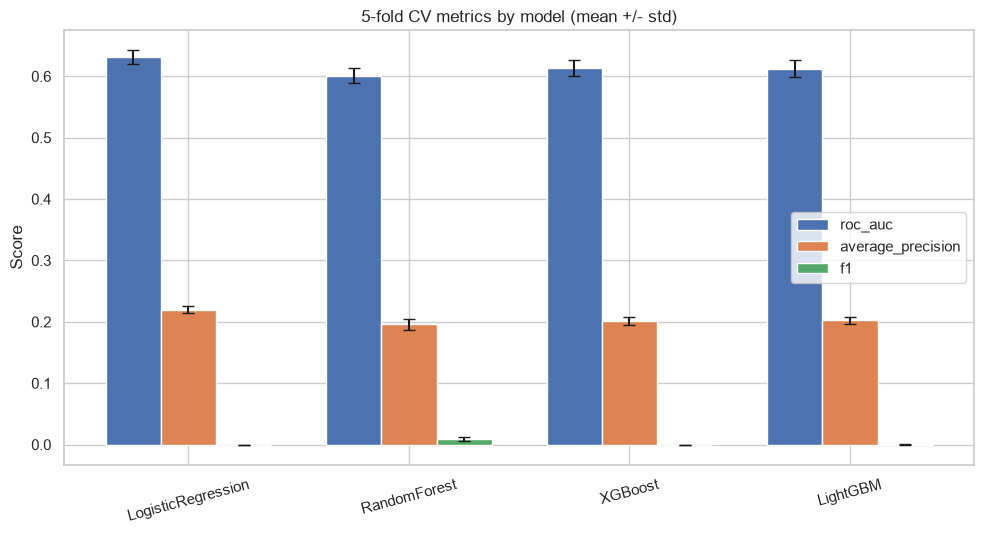

In [21]:
fig, ax = plt.subplots(figsize=(10, 5.5))
metrics_to_plot = ["roc_auc", "average_precision", "f1"]
x = np.arange(len(cv_results))
width = 0.25
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + (i - 1) * width, cv_results[f"{m}_mean"], width,
           yerr=cv_results[f"{m}_std"], capsize=4, label=m)
ax.set_xticks(x); ax.set_xticklabels(cv_results.index, rotation=15)
ax.set_ylabel("Score"); ax.set_title("5-fold CV metrics by model (mean +/- std)")
ax.legend()
fig.tight_layout()
savefig(fig, "response_cv_comparison.png")
plt.show()

In [22]:
# --- Fit each model on the full training set, evaluate on the held-out test set ---
fitted_models, test_metrics_rows = {}, []
for name, model in base_models.items():
    try:
        model.fit(X_train, y_train)
        fitted_models[name] = model
        proba = model.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)
        test_metrics_rows.append(dict(
            model=name,
            roc_auc=roc_auc_score(y_test, proba),
            pr_auc=average_precision_score(y_test, proba),
            precision=precision_score(y_test, pred, zero_division=0),
            recall=recall_score(y_test, pred, zero_division=0),
            f1=f1_score(y_test, pred, zero_division=0),
        ))
    except Exception as e:
        print(f"  {name:18s} FAILED on test evaluation: {type(e).__name__}: {e}")

test_metrics = pd.DataFrame(test_metrics_rows).set_index("model")
print("Held-out test-set metrics:")
display(test_metrics.round(4))

for name in fitted_models:
    proba = fitted_models[name].predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f"\nConfusion matrix — {name}:\n{confusion_matrix(y_test, pred)}")

Held-out test-set metrics:


,roc_auc,pr_auc,precision,recall,f1
model,,,,,
LogisticRegression,0.6384,0.2205,0.0000,0.0000,0.0000
RandomForest,0.6080,0.2012,0.2222,0.0011,0.0022
XGBoost,0.6206,0.2036,0.0000,0.0000,0.0000
LightGBM,0.6151,0.2033,0.0000,0.0000,0.0000



Confusion matrix — LogisticRegression:
[[10937     0]
 [ 1847     0]]

Confusion matrix — RandomForest:
[[10930     7]
 [ 1845     2]]

Confusion matrix — XGBoost:
[[10934     3]
 [ 1847     0]]

Confusion matrix — LightGBM:
[[10935     2]
 [ 1847     0]]


**Confusion matrices**, side by side, for all four base response models (threshold 0.5).

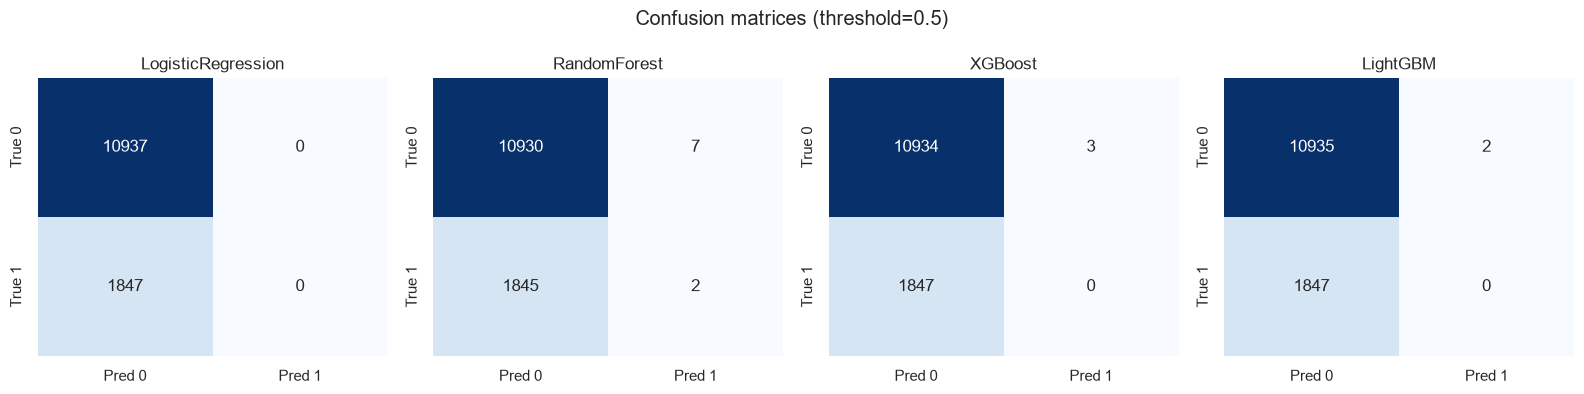

In [23]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(4 * len(fitted_models), 4))
if len(fitted_models) == 1:
    axes = [axes]
for ax, (name, model) in zip(axes, fitted_models.items()):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(name)
fig.suptitle("Confusion matrices (threshold=0.5)")
fig.tight_layout()
savefig(fig, "response_confusion_matrices.png")
plt.show()

In [24]:
# --- Hyperparameter tuning: RandomizedSearchCV on the top 2 models by CV ROC-AUC ---
top2 = cv_results["roc_auc_mean"].sort_values(ascending=False).index[:2].tolist()
print(f"Tuning top 2 models by CV ROC-AUC: {top2}")

param_grids = {
    "LogisticRegression": {"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10], "penalty": ["l2"]},
    "RandomForest": {"n_estimators": [100, 200, 300], "max_depth": [6, 8, 10, 12],
                      "min_samples_leaf": [1, 5, 20, 50]},
    "XGBoost": {"n_estimators": [100, 150, 200], "max_depth": [3, 4, 5, 6],
                "learning_rate": [0.03, 0.05, 0.1, 0.2], "subsample": [0.7, 0.85, 1.0]},
    "LightGBM": {"n_estimators": [100, 150, 200], "num_leaves": [7, 15, 31],
                 "learning_rate": [0.03, 0.05, 0.1, 0.2], "subsample": [0.7, 0.85, 1.0]},
}

tuned_models, tuning_rows = {}, []
for name in top2:
    try:
        search = RandomizedSearchCV(
            base_models[name].__class__(**{k: v for k, v in base_models[name].get_params().items()
                                             if k not in param_grids[name]}),
            param_distributions=param_grids[name], n_iter=8, cv=3, scoring="roc_auc",
            random_state=SEED, n_jobs=-1,
        )
        search.fit(X_train, y_train)
        tuned_models[name] = search.best_estimator_
        proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        tuning_rows.append(dict(model=name, best_cv_roc_auc=search.best_score_,
                                 test_roc_auc_after_tuning=roc_auc_score(y_test, proba),
                                 test_roc_auc_before_tuning=test_metrics.loc[name, "roc_auc"],
                                 best_params=search.best_params_))
        print(f"  {name}: best CV ROC-AUC={search.best_score_:.4f}  best params={search.best_params_}")
    except Exception as e:
        print(f"  {name} tuning FAILED: {type(e).__name__}: {e}")

tuning_df = pd.DataFrame(tuning_rows)
tuning_df[["model", "test_roc_auc_before_tuning", "test_roc_auc_after_tuning", "best_cv_roc_auc"]].round(4)

Tuning top 2 models by CV ROC-AUC: ['LogisticRegression', 'XGBoost']


  LogisticRegression: best CV ROC-AUC=0.6299  best params={'penalty': 'l2', 'C': 10}


  XGBoost: best CV ROC-AUC=0.6233  best params={'subsample': 0.7, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.03}


,model,test_roc_auc_before_tuning,test_roc_auc_after_tuning,best_cv_roc_auc
0,LogisticRegression,0.6384,0.6384,0.6299
1,XGBoost,0.6206,0.6300,0.6233


Best response model: LogisticRegression


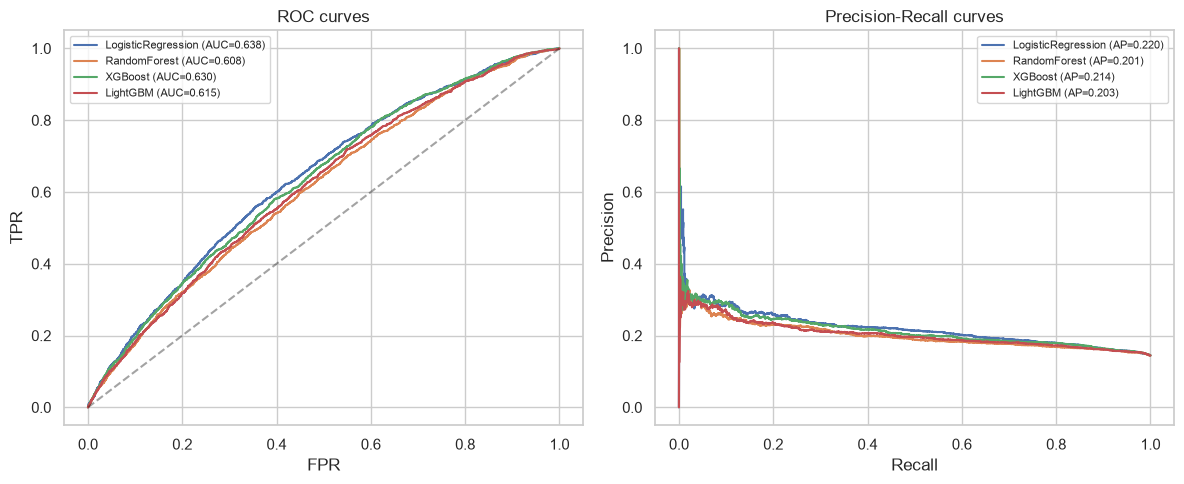

In [25]:
# --- Pick the single best model (post-tuning where available) for ROC/PR/calibration/SHAP ---
final_response_models = dict(fitted_models)
final_response_models.update(tuned_models)
best_response_name = max(
    final_response_models,
    key=lambda n: roc_auc_score(y_test, final_response_models[n].predict_proba(X_test)[:, 1])
)
best_response_model = final_response_models[best_response_name]
print(f"Best response model: {best_response_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, model in final_response_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC curves"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)
axes[1].set_title("Precision-Recall curves"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig(fig, "response_roc_pr_curves.png")
plt.show()

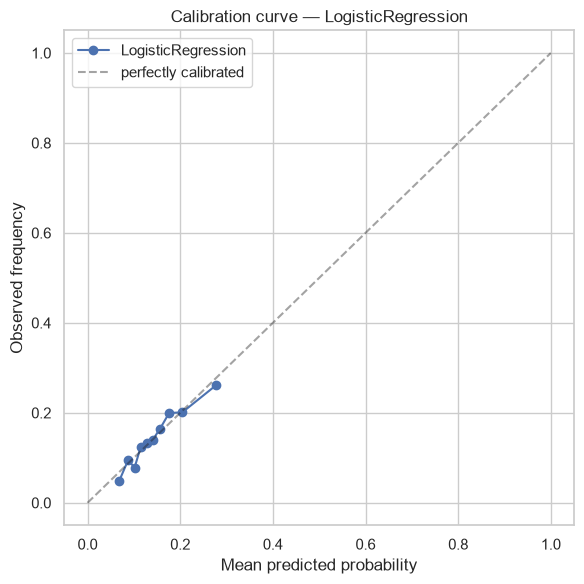

In [26]:
# --- Calibration curve for the best model ---
proba_best = best_response_model.predict_proba(X_test)[:, 1]
frac_pos, mean_pred = calibration_curve(y_test, proba_best, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, marker="o", label=best_response_name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title(f"Calibration curve — {best_response_name}")
ax.legend()
fig.tight_layout()
savefig(fig, "response_calibration_curve.png")
plt.show()

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


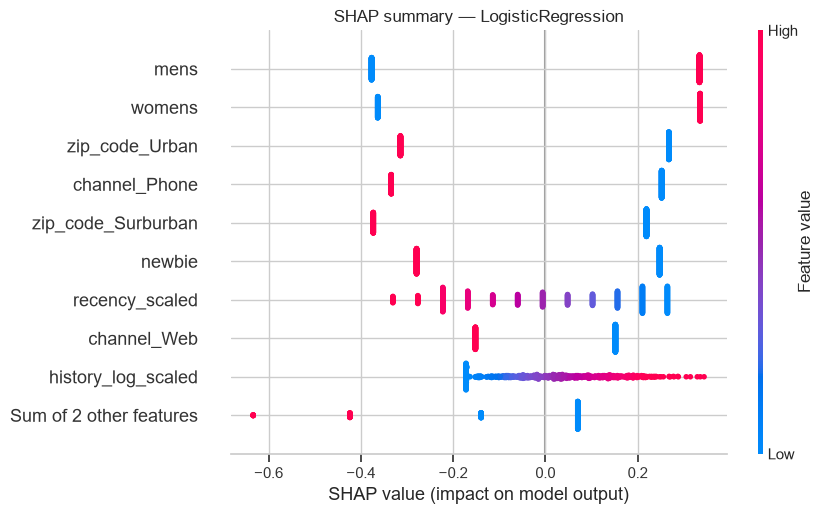

In [27]:
# --- SHAP summary plot for the best model ---
X_shap = X_test.sample(n=min(500, len(X_test)), random_state=SEED)
try:
    if isinstance(best_response_model, LogisticRegression):
        background = X_train.sample(n=min(200, len(X_train)), random_state=SEED)
        explainer = shap.LinearExplainer(best_response_model, background)
    else:
        explainer = shap.TreeExplainer(best_response_model)
    shap_values = explainer(X_shap)
    if len(shap_values.shape) == 3:  # (n, features, classes) -> keep positive class
        shap_values = shap_values[..., 1]
    fig = plt.figure(figsize=(8, 6))
    shap.plots.beeswarm(shap_values, show=False)
    plt.title(f"SHAP summary — {best_response_name}")
    savefig(plt.gcf(), "response_shap_summary.png")
    plt.show()
except Exception as e:
    print(f"SHAP FAILED: {type(e).__name__}: {e}")

**Why this is the wrong tool for targeting**: a response model ranks
customers by $P(\text{visit}\mid X)$ — how likely they are to convert,
period. A customer who was *always* going to visit regardless of the email
(a Sure Thing) gets the same high score as a customer who would only visit
*because* of the email (a Persuadable). Mailing the top-ranked customers by
response score therefore spends most of the budget on people the campaign
does not actually influence. What we actually want to rank by is not
$P(Y\mid X)$ but $P(Y\mid X, T{=}1) - P(Y\mid X, T{=}0)$ — the individual
**treatment effect**. That requires a fundamentally different kind of model,
built in Section 9.

## 9. Causal ML — Uplift Models

Three uplift ("meta") learners, all built manually on top of LightGBM base
learners (no causalml / econml / scikit-uplift). Each is introduced with its
own markdown explanation immediately before its code, plus a naive
`ResponseModel` (the same idea as Section 8, rebuilt as a single LightGBM
classifier) kept around purely as a non-causal baseline for the Qini/PEHE/
profit comparisons in Sections 10-14.

In [28]:
LGB_CLF_PARAMS = dict(n_estimators=150, max_depth=5, num_leaves=15, learning_rate=0.05,
                       min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                       random_state=SEED, verbose=-1, n_jobs=-1)
LGB_REG_PARAMS = dict(n_estimators=150, max_depth=5, num_leaves=15, learning_rate=0.05,
                       min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                       random_state=SEED, verbose=-1, n_jobs=-1)

def fit_response_model(train, feature_cols):
    """Naive baseline: ignores treatment, predicts P(outcome)."""
    m = lgb.LGBMClassifier(**LGB_CLF_PARAMS)
    m.fit(train[feature_cols], train["outcome"])
    def predict_tau(test):
        return m.predict_proba(test[feature_cols])[:, 1]  # NOT a real tau -- see markdown above
    def predict_baseline(test):
        return m.predict_proba(test[feature_cols])[:, 1]
    return predict_tau, predict_baseline

### S-Learner

A single model with **treatment folded in as an ordinary feature**. Predict
twice per customer — once forcing $T{=}1$, once forcing $T{=}0$ — and take
the difference: $\hat\tau(x) = \hat p(y\mid x, T{=}1) - \hat p(y\mid x, T{=}0)$.
Simplest possible uplift learner; its weakness is that a single tree-based
model can easily under-use the treatment feature if it's a weak
predictor relative to the other features.

In [29]:
def fit_s_learner(train, feature_cols):
    X = train[feature_cols].copy()
    X["treatment"] = train["treatment"].values
    m = lgb.LGBMClassifier(**LGB_CLF_PARAMS)
    m.fit(X, train["outcome"])
    def predict_tau(test):
        X1 = test[feature_cols].copy(); X1["treatment"] = 1
        X0 = test[feature_cols].copy(); X0["treatment"] = 0
        return m.predict_proba(X1)[:, 1] - m.predict_proba(X0)[:, 1]
    def predict_baseline(test):
        X0 = test[feature_cols].copy(); X0["treatment"] = 0
        return m.predict_proba(X0)[:, 1]
    return predict_tau, predict_baseline

### T-Learner

**Two entirely separate models**, one fit only on the treated arm, one fit
only on the control arm: $\hat\tau(x) = \hat\mu_1(x) - \hat\mu_0(x)$. No
information is shared between arms, so each model can specialize, but each
also sees only half the data (a problem in small or imbalanced-arm
settings).

In [30]:
def fit_t_learner(train, feature_cols):
    tr1 = train[train["treatment"] == 1]
    tr0 = train[train["treatment"] == 0]
    m1 = lgb.LGBMClassifier(**LGB_CLF_PARAMS); m1.fit(tr1[feature_cols], tr1["outcome"])
    m0 = lgb.LGBMClassifier(**LGB_CLF_PARAMS); m0.fit(tr0[feature_cols], tr0["outcome"])
    def predict_tau(test):
        return m1.predict_proba(test[feature_cols])[:, 1] - m0.predict_proba(test[feature_cols])[:, 1]
    def predict_baseline(test):
        return m0.predict_proba(test[feature_cols])[:, 1]
    return predict_tau, predict_baseline

### X-Learner

A two-stage learner designed for imbalanced treatment/control ratios.
**Stage 1** fits $\hat\mu_1$, $\hat\mu_0$ exactly like the T-learner.
**Stage 2** imputes an individual treatment effect for every unit using the
*other* arm's model as a counterfactual — $D_1 = Y - \hat\mu_0(X)$ for
treated units, $D_0 = \hat\mu_1(X) - Y$ for control units — and fits a
regressor to each imputed-effect set. **Stage 3** combines the two effect
regressors, weighted by an estimated propensity score
$g(x)=\hat P(T{=}1\mid x)$, so the arm with more data gets more weight:
$\hat\tau(x) = g(x)\hat\tau_0(x) + (1-g(x))\hat\tau_1(x)$.

In [31]:
def fit_x_learner(train, feature_cols):
    tr1 = train[train["treatment"] == 1]
    tr0 = train[train["treatment"] == 0]
    mu1 = lgb.LGBMClassifier(**LGB_CLF_PARAMS); mu1.fit(tr1[feature_cols], tr1["outcome"])
    mu0 = lgb.LGBMClassifier(**LGB_CLF_PARAMS); mu0.fit(tr0[feature_cols], tr0["outcome"])

    d1 = tr1["outcome"].values - mu0.predict_proba(tr1[feature_cols])[:, 1]
    d0 = mu1.predict_proba(tr0[feature_cols])[:, 1] - tr0["outcome"].values

    tau1_model = lgb.LGBMRegressor(**LGB_REG_PARAMS); tau1_model.fit(tr1[feature_cols], d1)
    tau0_model = lgb.LGBMRegressor(**LGB_REG_PARAMS); tau0_model.fit(tr0[feature_cols], d0)

    g = lgb.LGBMClassifier(**LGB_CLF_PARAMS); g.fit(train[feature_cols], train["treatment"])

    def predict_tau(test):
        gx = np.clip(g.predict_proba(test[feature_cols])[:, 1], 0.01, 0.99)
        return gx * tau0_model.predict(test[feature_cols]) + (1 - gx) * tau1_model.predict(test[feature_cols])
    def predict_baseline(test):
        return mu0.predict_proba(test[feature_cols])[:, 1]
    return predict_tau, predict_baseline

UPLIFT_MODEL_FITTERS = {
    "ResponseModel": fit_response_model,
    "SLearner": fit_s_learner,
    "TLearner": fit_t_learner,
    "XLearner": fit_x_learner,
}
print("Defined uplift model fitters:", list(UPLIFT_MODEL_FITTERS.keys()))

Defined uplift model fitters: ['ResponseModel', 'SLearner', 'TLearner', 'XLearner']


In [32]:
# --- Fit all four on the Hillstrom train split, predict on the test split ---
hillstrom_tau, hillstrom_baseline = {}, {}
for name, fitter in UPLIFT_MODEL_FITTERS.items():
    try:
        predict_tau, predict_baseline = fitter(train_df, FEATURE_COLS)
        hillstrom_tau[name] = predict_tau(test_df)
        hillstrom_baseline[name] = predict_baseline(test_df)
        print(f"  {name:14s} fit OK. tau range on test: "
              f"[{hillstrom_tau[name].min():+.4f}, {hillstrom_tau[name].max():+.4f}]  "
              f"mean={hillstrom_tau[name].mean():+.4f}")
    except Exception as e:
        print(f"  {name:14s} FAILED: {type(e).__name__}: {e}")

  ResponseModel  fit OK. tau range on test: [+0.0298, +0.4367]  mean=+0.1454


  SLearner       fit OK. tau range on test: [-0.0356, +0.2222]  mean=+0.0742


  TLearner       fit OK. tau range on test: [-0.1465, +0.3049]  mean=+0.0762


  XLearner       fit OK. tau range on test: [-0.0762, +0.2333]  mean=+0.0760


## 10. Uplift Evaluation

**The fundamental problem of causal inference**: for any single customer we
observe *either* their outcome under treatment *or* their outcome under
control, never both. There is no such thing as a "true uplift label" to
compute accuracy or AUC against for an individual. Every uplift metric below
works around this by comparing **groups**, not individuals: rank everyone by
predicted uplift, then check whether the *treatment-minus-control gap in
observed outcomes* actually grows as we move through higher-ranked people.

All four metrics below are implemented from scratch:

- **Qini curve / Qini coefficient** — cumulative
  $Y_1(t) - Y_0(t)\cdot N_1(t)/N_0(t)$ as we target the top $t$ fraction,
  compared against the area under the random-targeting diagonal.
- **Uplift curve / AUUC** — the same idea, but scaled by total population
  size in the top $t$ fraction rather than by the treatment-arm ratio.
- **Cumulative gain at top 10/20/30%** — the uplift-curve value read off at
  three fixed depths, i.e. "how much incremental conversion do we capture by
  only targeting the top X%".

In [33]:
def qini_curve_values(y, t, pred, n_bins=100):
    order = np.argsort(-pred)
    y, t = y[order], t[order]
    n = len(y)
    cum_y1, cum_n1 = np.cumsum(y * t), np.cumsum(t)
    cum_y0, cum_n0 = np.cumsum(y * (1 - t)), np.cumsum(1 - t)
    idx = (np.linspace(1, n, min(n_bins, n))).astype(int) - 1
    Y1, N1, Y0, N0 = cum_y1[idx], cum_n1[idx], cum_y0[idx], cum_n0[idx]
    ratio = np.divide(N1, N0, out=np.zeros_like(N1, dtype=float), where=N0 > 0)
    qini = Y1 - Y0 * ratio
    frac = np.concatenate(([0.0], (idx + 1) / n))
    qini = np.concatenate(([0.0], qini))
    return frac, qini

def qini_coefficient(y, t, pred):
    frac, qini = qini_curve_values(y, t, pred)
    return float(np.trapezoid(qini, frac) - qini[-1] / 2.0)

def uplift_curve_values(y, t, pred, n_bins=100):
    order = np.argsort(-pred)
    y, t = y[order], t[order]
    n = len(y)
    cum_y1, cum_n1 = np.cumsum(y * t), np.cumsum(t)
    cum_y0, cum_n0 = np.cumsum(y * (1 - t)), np.cumsum(1 - t)
    idx = (np.linspace(1, n, min(n_bins, n))).astype(int) - 1
    Y1, N1, Y0, N0 = cum_y1[idx], cum_n1[idx], cum_y0[idx], cum_n0[idx]
    rate1 = np.divide(Y1, N1, out=np.zeros_like(Y1, dtype=float), where=N1 > 0)
    rate0 = np.divide(Y0, N0, out=np.zeros_like(Y0, dtype=float), where=N0 > 0)
    curve = (rate1 - rate0) * (N1 + N0)
    frac = np.concatenate(([0.0], (idx + 1) / n))
    curve = np.concatenate(([0.0], curve))
    return frac, curve

def auuc(y, t, pred, n_bins=100):
    frac, curve = uplift_curve_values(y, t, pred, n_bins=n_bins)
    return float(np.trapezoid(curve, frac))

def cumulative_gain_at_k(y, t, pred, k_fracs=(0.1, 0.2, 0.3)):
    frac, curve = uplift_curve_values(y, t, pred, n_bins=200)
    out = {}
    for k in k_fracs:
        idx = np.searchsorted(frac, k)
        idx = min(idx, len(curve) - 1)
        out[k] = curve[idx]
    return out

def pehe(true_cate, pred_cate):
    """True error vs ground-truth CATE. Only valid when true_cate is known (Section 13)."""
    return float(np.sqrt(np.mean((true_cate - pred_cate) ** 2)))

def expected_profit(pred_cate, treatment, outcome, cost=2, margin=200):
    """Transformed-outcome profit estimate at targeting depths 10..100%."""
    n = len(pred_cate)
    p = np.clip(treatment.mean(), 1e-4, 1 - 1e-4)
    z = outcome * treatment / p - outcome * (1 - treatment) / (1 - p)
    order = np.argsort(-pred_cate)
    z_sorted = z[order]
    depths = np.arange(10, 101, 10)
    profits = np.array([margin * z_sorted[:max(int(n * d / 100), 1)].sum()
                         - cost * max(int(n * d / 100), 1) for d in depths])
    best_i = int(np.argmax(profits))
    return depths, profits, depths[best_i], profits[best_i]

print("Metric functions defined: qini_curve_values, qini_coefficient, uplift_curve_values,",
      "auuc, cumulative_gain_at_k, pehe, expected_profit")

Metric functions defined: qini_curve_values, qini_coefficient, uplift_curve_values, auuc, cumulative_gain_at_k, pehe, expected_profit


In [34]:
y_test_arr = test_df["outcome"].values
t_test_arr = test_df["treatment"].values

hillstrom_metric_rows = []
hillstrom_qini_curves = {}
for name in UPLIFT_MODEL_FITTERS:
    if name not in hillstrom_tau:
        continue
    pred = hillstrom_tau[name]
    q = qini_coefficient(y_test_arr, t_test_arr, pred)
    a = auuc(y_test_arr, t_test_arr, pred)
    gains = cumulative_gain_at_k(y_test_arr, t_test_arr, pred)
    hillstrom_qini_curves[name] = qini_curve_values(y_test_arr, t_test_arr, pred, n_bins=50)
    hillstrom_metric_rows.append(dict(model=name, qini=q, auuc=a,
                                       gain_at_10pct=gains[0.1], gain_at_20pct=gains[0.2],
                                       gain_at_30pct=gains[0.3]))

hillstrom_uplift_metrics = pd.DataFrame(hillstrom_metric_rows).set_index("model")
print("Hillstrom uplift metrics (real data — no ground truth, so PEHE is NOT reported here):")
display(hillstrom_uplift_metrics.round(3))

Hillstrom uplift metrics (real data — no ground truth, so PEHE is NOT reported here):


,qini,auuc,gain_at_10pct,gain_at_20pct,gain_at_30pct
model,,,,,
ResponseModel,6.986,504.145,135.325,236.205,328.984
SLearner,-2.185,487.174,138.075,225.133,323.521
TLearner,0.953,490.703,116.948,197.318,317.477
XLearner,2.958,496.536,134.796,199.058,311.748


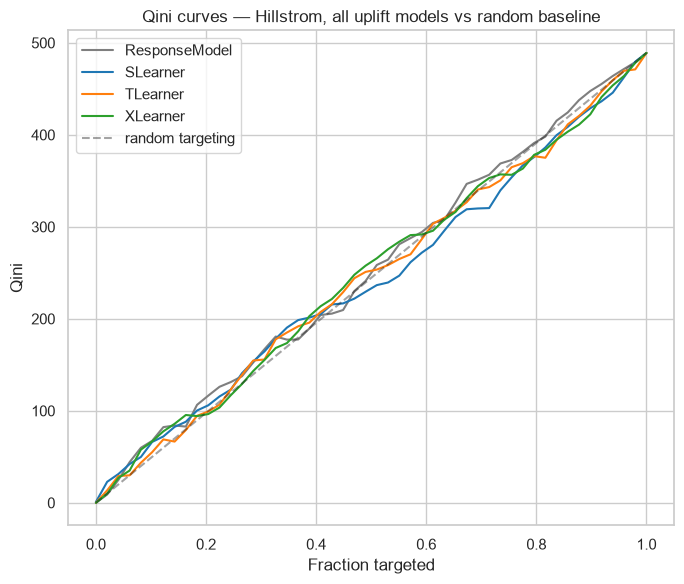

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = {"ResponseModel": "tab:gray", "SLearner": "tab:blue", "TLearner": "tab:orange", "XLearner": "tab:green"}
for name, (frac, qini) in hillstrom_qini_curves.items():
    ax.plot(frac, qini, label=name, color=colors.get(name))
any_end = next(iter(hillstrom_qini_curves.values()))[1][-1]
ax.plot([0, 1], [0, any_end], "k--", alpha=0.4, label="random targeting")
ax.set_xlabel("Fraction targeted"); ax.set_ylabel("Qini")
ax.set_title("Qini curves — Hillstrom, all uplift models vs random baseline")
ax.legend()
fig.tight_layout()
savefig(fig, "uplift_qini_curves_hillstrom.png")
plt.show()

**Cumulative gain at fixed depths**: how much incremental conversion each model captures by targeting only its top 10/20/30% — a business-readable complement to the Qini curve.

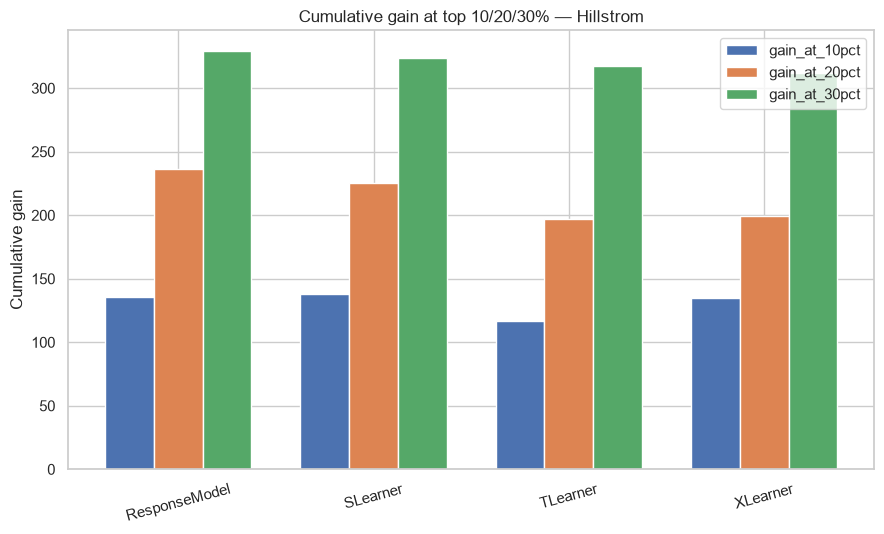

In [36]:
gain_cols = ["gain_at_10pct", "gain_at_20pct", "gain_at_30pct"]
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(hillstrom_uplift_metrics))
width = 0.25
for i, col in enumerate(gain_cols):
    ax.bar(x + (i - 1) * width, hillstrom_uplift_metrics[col], width, label=col)
ax.set_xticks(x); ax.set_xticklabels(hillstrom_uplift_metrics.index, rotation=15)
ax.axhline(0, color="k", linewidth=0.6)
ax.set_ylabel("Cumulative gain"); ax.set_title("Cumulative gain at top 10/20/30% — Hillstrom")
ax.legend()
fig.tight_layout()
savefig(fig, "uplift_cumulative_gain.png")
plt.show()

## 11. Unsupervised Learning Part 3 — Discovering the Four Customer Types

**Key section.** We take the *best* causal model's predicted individual
uplift $\hat\tau(x)$ together with its predicted **baseline conversion
probability** $\hat\mu_0(x)$ (the control-arm prediction each learner
already produces internally), and run **K-Means with $k=4$** on that 2D
space — nothing else, no demographic features, no labels. If the theory in
Section 1 is right, the four clusters K-Means finds on its own should line
up with Persuadables (high uplift), Sure Things (high baseline, low
uplift), Lost Causes (low baseline, low uplift), and Sleeping Dogs (negative
uplift).

In [37]:
best_uplift_name = hillstrom_uplift_metrics.drop(index="ResponseModel", errors="ignore")["qini"].idxmax()
print(f"Best causal uplift model by Qini coefficient: {best_uplift_name}")

tau_best = hillstrom_tau[best_uplift_name]
baseline_best = hillstrom_baseline[best_uplift_name]

space = np.column_stack([tau_best, baseline_best])
space_scaled = StandardScaler().fit_transform(space)

kmeans_uplift = KMeans(n_clusters=4, random_state=SEED, n_init=10)
uplift_cluster = kmeans_uplift.fit_predict(space_scaled)

type_df = pd.DataFrame({"tau": tau_best, "baseline": baseline_best, "cluster": uplift_cluster},
                        index=test_df.index)

# --- Auto-label clusters from their own centroids: no hand-picked thresholds ---
# Every cluster gets exactly one label: rank by mean tau, extremes are
# Persuadables (highest) / Sleeping-Dogs-candidate (lowest); the middle two
# are split by mean baseline into Sure Things (higher) / Lost Causes (lower).
centroids = type_df.groupby("cluster")[["tau", "baseline"]].mean()
by_tau = centroids["tau"].sort_values(ascending=False)
labels = pd.Series(index=centroids.index, dtype=object)

persuadable_cluster = by_tau.index[0]
sleeping_cluster = by_tau.index[-1]
labels[persuadable_cluster] = "Persuadables"

sleeping_is_negative = centroids.loc[sleeping_cluster, "tau"] < 0
labels[sleeping_cluster] = "Sleeping Dogs" if sleeping_is_negative else "Sleeping Dogs (weakest uplift, still >=0)"

middle = centroids.drop(index=[persuadable_cluster, sleeping_cluster])
sure_thing = middle["baseline"].idxmax()
lost_cause = middle["baseline"].idxmin()
labels[sure_thing] = "Sure Things"
labels[lost_cause] = "Lost Causes"

type_df["business_label"] = type_df["cluster"].map(labels)
print("\nAuto-derived cluster -> business-type mapping (ranked by centroid tau/baseline, no manual thresholds):")
print(labels)
if not sleeping_is_negative:
    print("\nNote: even the lowest-uplift cluster has a non-negative mean tau in this fit -- "
          "no true Sleeping Dogs (negative treatment effect) were found in this real dataset/model. "
          "Section 13's synthetic sleeping_dogs scenario forces a genuine negative-effect subpopulation "
          "to demonstrate that case explicitly.")

Best causal uplift model by Qini coefficient: XLearner

Auto-derived cluster -> business-type mapping (ranked by centroid tau/baseline, no manual thresholds):
cluster
0                                  Lost Causes
1                                 Persuadables
2                                  Sure Things
3    Sleeping Dogs (weakest uplift, still >=0)
dtype: object

Note: even the lowest-uplift cluster has a non-negative mean tau in this fit -- no true Sleeping Dogs (negative treatment effect) were found in this real dataset/model. Section 13's synthetic sleeping_dogs scenario forces a genuine negative-effect subpopulation to demonstrate that case explicitly.


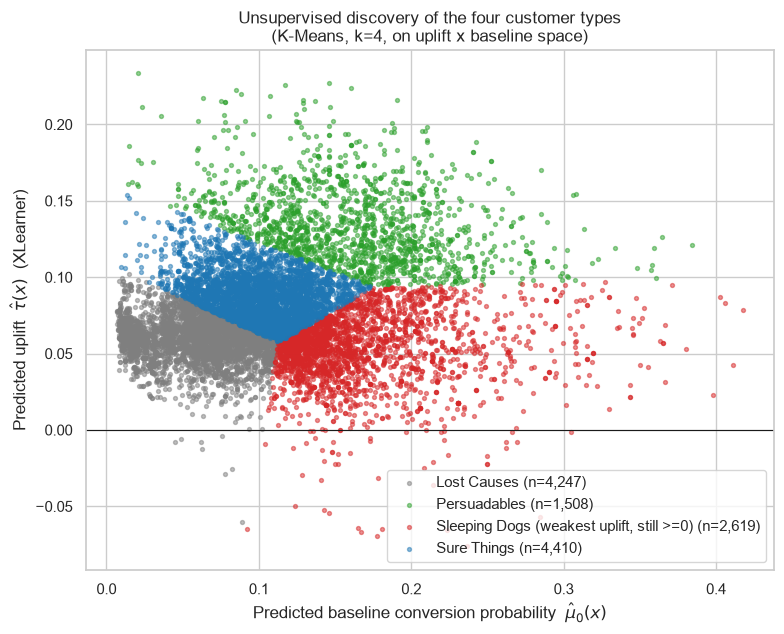

In [38]:
fig, ax = plt.subplots(figsize=(8, 6.5))
palette = {"Persuadables": "tab:green", "Sure Things": "tab:blue",
           "Lost Causes": "tab:gray", "Sleeping Dogs": "tab:red"}
def color_for(lbl):
    for key, color in palette.items():
        if lbl.startswith(key):
            return color
    return "black"
for lbl, sub in type_df.groupby("business_label"):
    ax.scatter(sub["baseline"], sub["tau"], s=8, alpha=0.5,
               label=f"{lbl} (n={len(sub):,})", color=color_for(lbl))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("Predicted baseline conversion probability  $\\hat\\mu_0(x)$")
ax.set_ylabel(f"Predicted uplift  $\\hat\\tau(x)$  ({best_uplift_name})")
ax.set_title("Unsupervised discovery of the four customer types\n(K-Means, k=4, on uplift x baseline space)")
ax.legend()
fig.tight_layout()
savefig(fig, "uplift_four_customer_types.png")
plt.show()

In [39]:
type_summary = type_df.groupby("business_label").agg(
    n=("tau", "size"), mean_uplift=("tau", "mean"), mean_baseline=("baseline", "mean")
).round(4)
type_summary["pct_of_customers"] = (type_summary["n"] / len(type_df) * 100).round(1)
print("Discovered customer-type table:")
display(type_summary)

# --- Cross-tab against the Section 5 demographic clusters ---
demo_for_test = kmeans_demo.predict(test_df[FEATURE_COLS].values)
crosstab = pd.crosstab(pd.Series(demo_for_test, index=test_df.index, name="demo_cluster"),
                        type_df["business_label"])
print("\nCross-tab: Section 5 demographic clusters x Section 11 uplift-type clusters")
display(crosstab)

Discovered customer-type table:


,n,mean_uplift,mean_baseline,pct_of_customers
business_label,,,,
Lost Causes,4247,0.0586,0.0581,33.2
Persuadables,1508,0.1343,0.1613,11.8
"Sleeping Dogs (weakest uplift, still >=0)",2619,0.0529,0.1670,20.5
Sure Things,4410,0.0866,0.1009,34.5



Cross-tab: Section 5 demographic clusters x Section 11 uplift-type clusters


business_label,Lost Causes,Persuadables,"Sleeping Dogs (weakest uplift, still >=0)",Sure Things
demo_cluster,,,,
0,319,1084,981,1103
1,1041,82,640,1580
2,1690,1,209,849
3,1197,341,789,878


**Visualizing the cross-tab**: row-normalized, so each demographic cluster's row shows its own mix of uplift types.

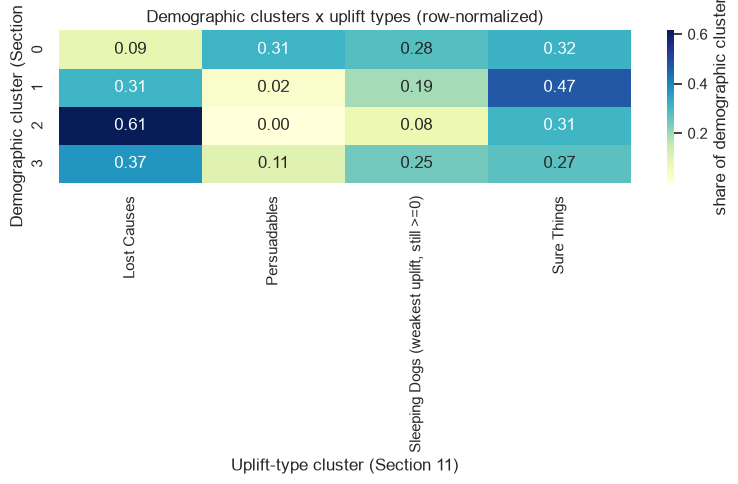

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)
sns.heatmap(crosstab_norm, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "share of demographic cluster"})
ax.set_xlabel("Uplift-type cluster (Section 11)"); ax.set_ylabel("Demographic cluster (Section 5)")
ax.set_title("Demographic clusters x uplift types (row-normalized)")
fig.tight_layout()
savefig(fig, "uplift_type_crosstab_heatmap.png")
plt.show()

We recovered the theoretical Persuadables / Sure Things / Lost Causes /
Sleeping Dogs structure **from the data itself**, using only an unsupervised
clustering algorithm on two model-derived scores — no marketing theory was
hard-coded into the clustering, only used afterward to *label* the clusters
K-Means already found. The cross-tab against the purely demographic
clusters from Section 5 shows that a customer's uplift *type* is not simply
a repackaging of their demographic segment — the two clusterings capture
different structure in the same customers.

## 12. Profit Optimization

`expected_profit` (Section 10) uses the transformed-outcome estimator
$Z = Y\cdot T/p - Y\cdot(1-T)/(1-p)$, which stays an unbiased estimate of
individual treatment effect under random assignment even though we only
ever observe one arm per customer — so we can sweep it across targeting
depths for **every** model, including the plain response model (Section 8's
predicted probability used as the ranking) and "target everyone" (which is
just the profit at depth 100%, identical for any ranking since it targets
the whole population regardless of order).

Assumed campaign economics: **$2 cost per email contacted, $200 profit per
conversion** (kept from the earlier synthetic-data project for consistency;
varied explicitly in the sensitivity analysis below).

In [41]:
COST_PER_CONTACT = 2
PROFIT_PER_CONVERSION = 200

profit_curves = {}
profit_summary_rows = []
for name in UPLIFT_MODEL_FITTERS:
    if name not in hillstrom_tau:
        continue
    depths, profits, opt_depth, max_profit = expected_profit(
        hillstrom_tau[name], t_test_arr, y_test_arr, cost=COST_PER_CONTACT, margin=PROFIT_PER_CONVERSION
    )
    profit_curves[name] = (depths, profits)
    profit_summary_rows.append(dict(model=name, optimal_depth_pct=opt_depth, max_profit=max_profit,
                                     profit_target_everyone=profits[-1]))

# response model (Section 8) ranking, scored the same way
resp_proba_test = best_response_model.predict_proba(test_df[FEATURE_COLS])[:, 1]
depths_r, profits_r, opt_depth_r, max_profit_r = expected_profit(
    resp_proba_test, t_test_arr, y_test_arr, cost=COST_PER_CONTACT, margin=PROFIT_PER_CONVERSION
)
profit_curves[f"ResponseModel_S8 ({best_response_name})"] = (depths_r, profits_r)

profit_summary = pd.DataFrame(profit_summary_rows).set_index("model")
print("Profit summary (Hillstrom, uplift-model rankings):")
display(profit_summary.round(1))
print(f"\nSection-8 response model ({best_response_name}) ranking: "
      f"optimal depth={opt_depth_r}%  max profit=${max_profit_r:,.1f}")

pop_mean_z_margin = (y_test_arr * t_test_arr / t_test_arr.mean()
                      - y_test_arr * (1 - t_test_arr) / (1 - t_test_arr.mean())).mean() * PROFIT_PER_CONVERSION
print(f"\nDiagnostic: population-average expected revenue per contact = "
      f"{PROFIT_PER_CONVERSION} x mean(Z) = ${pop_mean_z_margin:.2f}, vs cost ${COST_PER_CONTACT}.")
if pop_mean_z_margin > COST_PER_CONTACT:
    print("Because that population-average margin already clears the contact cost by a wide margin, "
          "EVERY model (even a random ranking) finds depth=100% optimal at these unit economics -- "
          "targeting everyone is genuinely profit-optimal here, not a modelling artifact. "
          "The sensitivity heatmap below shows where that stops being true.")

Profit summary (Hillstrom, uplift-model rankings):


,optimal_depth_pct,max_profit,profit_target_everyone
model,,,
ResponseModel,100,170032.0,170032.0
SLearner,100,170032.0,170032.0
TLearner,100,170032.0,170032.0
XLearner,100,170032.0,170032.0



Section-8 response model (LogisticRegression) ranking: optimal depth=100%  max profit=$170,032.0

Diagnostic: population-average expected revenue per contact = 200 x mean(Z) = $15.30, vs cost $2.
Because that population-average margin already clears the contact cost by a wide margin, EVERY model (even a random ranking) finds depth=100% optimal at these unit economics -- targeting everyone is genuinely profit-optimal here, not a modelling artifact. The sensitivity heatmap below shows where that stops being true.


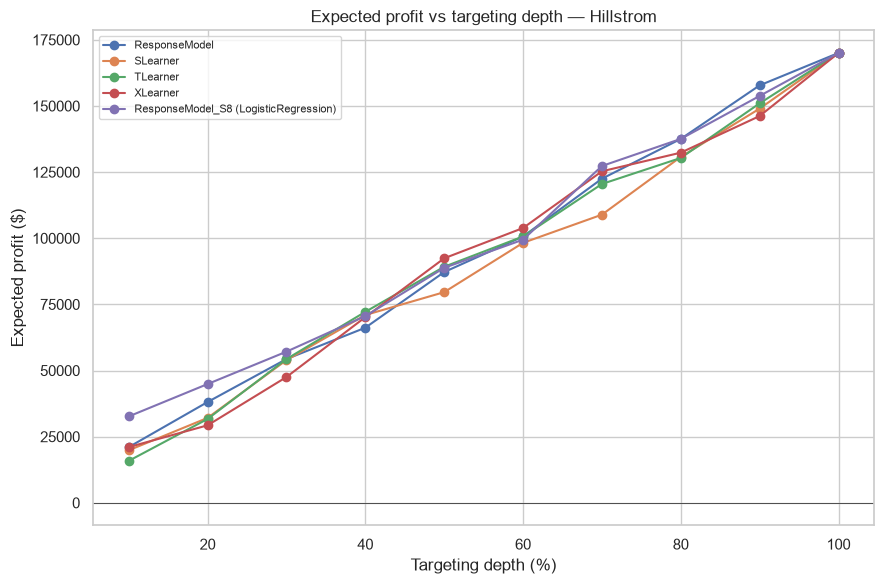

In [42]:
fig, ax = plt.subplots(figsize=(9, 6))
for name, (depths, profits) in profit_curves.items():
    ax.plot(depths, profits, marker="o", label=name)
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("Targeting depth (%)"); ax.set_ylabel("Expected profit ($)")
ax.set_title("Expected profit vs targeting depth — Hillstrom")
ax.legend(fontsize=8)
fig.tight_layout()
savefig(fig, "profit_vs_depth_hillstrom.png")
plt.show()

**Sensitivity analysis**: the flat result above is entirely a property
of the $200/$2 price ratio, not of model quality. We sweep both parameters
for the Qini-best causal model from Section 11 and plot the resulting
optimal targeting depth as a heatmap — this is where uplift targeting is
expected to start earning its keep, i.e. wherever the optimal depth drops
meaningfully below 100%.

Sensitivity analysis uses: XLearner (Qini-best causal model)


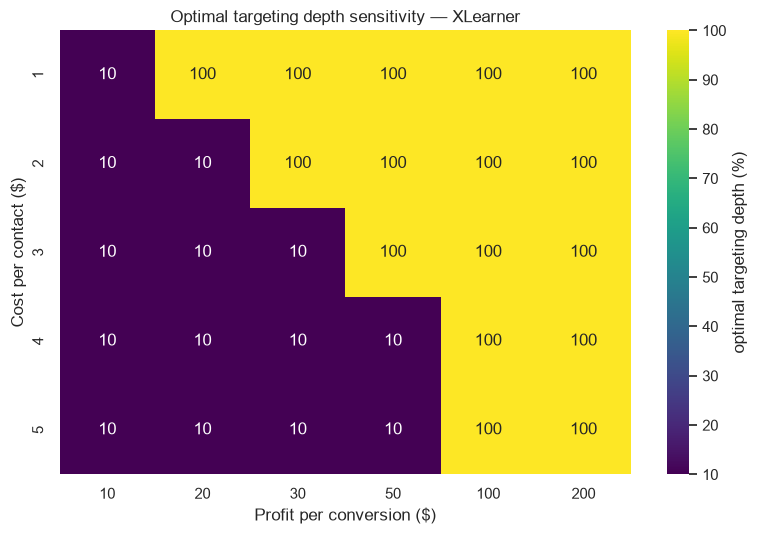

In [43]:
# --- Sensitivity analysis: optimal depth across a grid of cost / profit-per-conversion ---
# Use the Qini-best CAUSAL model from Section 11 (not a max_profit tie-break,
# which trivially favors whichever model is listed first when every model ties).
tau_grid_model = hillstrom_tau[best_uplift_name]
print(f"Sensitivity analysis uses: {best_uplift_name} (Qini-best causal model)")

costs = [1, 2, 3, 4, 5]
margins = [10, 20, 30, 50, 100, 200]
depth_grid = np.zeros((len(costs), len(margins)))
for i, c in enumerate(costs):
    for j, m in enumerate(margins):
        _, _, od, _ = expected_profit(tau_grid_model, t_test_arr, y_test_arr, cost=c, margin=m)
        depth_grid[i, j] = od

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(depth_grid, annot=True, fmt=".0f", cmap="viridis",
            xticklabels=margins, yticklabels=costs, ax=ax,
            cbar_kws={"label": "optimal targeting depth (%)"})
ax.set_xlabel("Profit per conversion ($)"); ax.set_ylabel("Cost per contact ($)")
ax.set_title(f"Optimal targeting depth sensitivity — {best_uplift_name}")
fig.tight_layout()
savefig(fig, "profit_sensitivity_heatmap.png")
plt.show()

**Final business table**: reported at two economics regimes — the
required $2/$200 defaults (where Section 12's diagnostic above already
explains why all three policies tie), and a second, higher-cost/lower-margin
regime read directly off the heatmap, where uplift targeting is expected to
pull ahead of both "target everyone" and response-model targeting.

In [44]:
def business_table_at(cost, margin, label):
    depths_e, profits_e, od_e, mp_e = expected_profit(tau_grid_model, t_test_arr, y_test_arr, cost=cost, margin=margin)
    depths_resp, profits_resp, od_resp, mp_resp = expected_profit(resp_proba_test, t_test_arr, y_test_arr, cost=cost, margin=margin)
    everyone_profit = profits_e[-1]
    table = pd.DataFrame([
        dict(policy="(a) Target everyone", profit=everyone_profit, depth_pct=100),
        dict(policy=f"(b) Target by response model ({best_response_name})", profit=mp_resp, depth_pct=od_resp),
        dict(policy=f"(c) Target by uplift model ({best_uplift_name})", profit=mp_e, depth_pct=od_e),
    ]).set_index("policy")
    table["gain_vs_target_everyone"] = table["profit"] - everyone_profit
    print(f"\nFinal business table — Hillstrom, {label} (cost=${cost}, margin=${margin}):")
    display(table.round(1))
    return table

business_table_default = business_table_at(COST_PER_CONTACT, PROFIT_PER_CONVERSION, "required default economics")
business_table_stricter = business_table_at(5, 20, "stricter economics (higher cost, lower margin)")


Final business table — Hillstrom, required default economics (cost=$2, margin=$200):


,profit,depth_pct,gain_vs_target_everyone
policy,,,
(a) Target everyone,170032.0,100,0.0
(b) Target by response model (LogisticRegression),170032.0,100,0.0
(c) Target by uplift model (XLearner),170032.0,100,0.0



Final business table — Hillstrom, stricter economics (higher cost, lower margin) (cost=$5, margin=$20):


,profit,depth_pct,gain_vs_target_everyone
policy,,,
(a) Target everyone,-44360.0,100,0.0
(b) Target by response model (LogisticRegression),-2870.0,10,41490.0
(c) Target by uplift model (XLearner),-4030.0,10,40330.0


## 13. Synthetic Validation — Establishing Ground Truth

On the real Hillstrom data, the true individual uplift is fundamentally
**unobservable** (Section 10) — so there is no way to check whether Qini,
AUUC, or profit are actually pointing at the "right" model in any absolute
sense; we can only check them against *each other*. To answer RQ3 properly
we need a dataset where we secretly *do* know the truth.

We generate synthetic RCT data with a known nonlinear `true_cate` (driven by
3 of 10 features), across four scenarios that stress different failure
modes: `easy` (large, well-behaved effect), `rare_conversion` (1% base
rate), `imbalanced` (85/15 treatment/control split), and `sleeping_dogs`
(30% of customers have a *negative* true effect). Because `true_cate` is
known here, we can finally compute **PEHE** — the true error — and see
whether Qini's #1 pick is actually the best model, or just looks like it.

In [45]:
N_FEATURES_SYNTH = 10
SYNTH_FEATURE_COLS = [f"x{i}" for i in range(N_FEATURES_SYNTH)]
N_ROWS_SYNTH = 50000

SYNTH_SCENARIOS = {
    "easy":            dict(base_rate=0.10, heterogeneity="high", treatment_ratio=0.5,  sleeping_dog_frac=0.10),
    "rare_conversion": dict(base_rate=0.01, heterogeneity="high", treatment_ratio=0.5,  sleeping_dog_frac=0.10),
    "imbalanced":      dict(base_rate=0.05, heterogeneity="med",  treatment_ratio=0.85, sleeping_dog_frac=0.10),
    "sleeping_dogs":   dict(base_rate=0.05, heterogeneity="high", treatment_ratio=0.5,  sleeping_dog_frac=0.30),
}

def generate_synthetic(n, base_rate, heterogeneity, treatment_ratio, sleeping_dog_frac, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, N_FEATURES_SYNTH))
    x0, x1, x2 = X[:, 0], X[:, 1], X[:, 2]
    raw = np.tanh(x0) + 0.5 * np.sin(2 * x1) + 0.3 * x0 * x2
    het_scale = {"high": 0.20, "med": 0.10, "low": 0.05}[heterogeneity]
    tau = het_scale * raw / raw.std()
    if sleeping_dog_frac > 0:
        sd_mask = rng.random(n) < sleeping_dog_frac
        tau = np.where(sd_mask, -np.abs(tau), tau)

    def logit(p): return np.log(p / (1 - p))
    def sigmoid(z): return 1 / (1 + np.exp(-z))

    x3, x4, x5 = X[:, 3], X[:, 4], X[:, 5]
    base_logit = logit(np.clip(base_rate, 1e-4, 1 - 1e-4))
    p_control = np.clip(sigmoid(base_logit + 0.4 * x3 - 0.3 * x4 + 0.2 * x5), 0.001, 0.999)
    p_treat = np.clip(p_control + tau, 0.0, 1.0)

    treatment = (rng.random(n) < treatment_ratio).astype(int)
    p_realized = np.where(treatment == 1, p_treat, p_control)
    outcome = (rng.random(n) < p_realized).astype(int)

    out = pd.DataFrame({f"x{i}": X[:, i] for i in range(N_FEATURES_SYNTH)})
    out["treatment"] = treatment
    out["outcome"] = outcome
    out["true_cate"] = tau
    return out

print("Synthetic simulator + scenarios defined:", list(SYNTH_SCENARIOS.keys()))

Synthetic simulator + scenarios defined: ['easy', 'rare_conversion', 'imbalanced', 'sleeping_dogs']


In [46]:
synth_table_a_rows, synth_qini_curves, synth_profit_curves = [], {}, {}

for scen_name, params in SYNTH_SCENARIOS.items():
    print(f"\n{'='*60}\nSCENARIO: {scen_name}  {params}\n{'='*60}")
    sdf = generate_synthetic(N_ROWS_SYNTH, seed=SEED, **params)
    strain, stest = train_test_split(sdf, test_size=0.3, random_state=SEED, stratify=sdf["treatment"])
    ys, ts, taus = stest["outcome"].values, stest["treatment"].values, stest["true_cate"].values

    synth_qini_curves[scen_name], synth_profit_curves[scen_name] = {}, {}
    for name, fitter in UPLIFT_MODEL_FITTERS.items():
        try:
            predict_tau, _ = fitter(strain, SYNTH_FEATURE_COLS)
            pred = predict_tau(stest)
            q = qini_coefficient(ys, ts, pred)
            a = auuc(ys, ts, pred)
            pe = pehe(taus, pred)
            depths, profits, opt_depth, max_profit = expected_profit(pred, ts, ys)
            synth_qini_curves[scen_name][name] = qini_curve_values(ys, ts, pred, n_bins=50)
            synth_profit_curves[scen_name][name] = (depths, profits)
            synth_table_a_rows.append(dict(scenario=scen_name, model=name, qini=q, auuc=a,
                                            pehe=pe, max_profit=max_profit, opt_depth=opt_depth))
            print(f"  {name:14s} qini={q:8.3f}  auuc={a:9.3f}  pehe={pe:.4f}  "
                  f"max_profit={max_profit:10.1f}  opt_depth={opt_depth}%")
        except Exception as e:
            print(f"  {name:14s} FAILED: {type(e).__name__}: {e}")

synth_table_a = pd.DataFrame(synth_table_a_rows)
print("\n\nTable A — synthetic scenario x model metrics:")
synth_table_a.round(3)


SCENARIO: easy  {'base_rate': 0.1, 'heterogeneity': 'high', 'treatment_ratio': 0.5, 'sleeping_dog_frac': 0.1}


  ResponseModel  qini= 193.389  auuc=  577.716  pehe=0.2155  max_profit=  133638.0  opt_depth=40%


  SLearner       qini= 254.579  auuc=  702.531  pehe=0.1407  max_profit=  167590.2  opt_depth=40%


  TLearner       qini= 254.398  auuc=  701.034  pehe=0.1361  max_profit=  165501.2  opt_depth=50%


  XLearner       qini= 255.462  auuc=  704.951  pehe=0.1310  max_profit=  165577.1  opt_depth=40%

SCENARIO: rare_conversion  {'base_rate': 0.01, 'heterogeneity': 'high', 'treatment_ratio': 0.5, 'sleeping_dog_frac': 0.1}
  ResponseModel  qini= 179.033  auuc=  834.132  pehe=0.1775  max_profit=  183409.0  opt_depth=50%


...

  SLearner       qini= 199.209  auuc=  303.307  pehe=0.0747  max_profit=   74294.8  opt_depth=40%
  TLearner       qini= 185.863  auuc=  287.563  pehe=0.0782  max_profit=   67658.7  opt_depth=40%


  XLearner       qini= 173.375  auuc=  273.112  pehe=0.0739  max_profit=   66909.5  opt_depth=50%

SCENARIO: sleeping_dogs  {'base_rate': 0.05, 'heterogeneity': 'high', 'treatment_ratio': 0.5, 'sleeping_dog_frac': 0.3}
  ResponseModel  qini= 132.335  auuc=  452.629  pehe=0.2110  max_profit=  103945.3  opt_depth=50%


  SLearner       qini= 163.348  auuc=  517.135  pehe=0.1804  max_profit=  115917.6  opt_depth=50%
  TLearner       qini= 161.681  auuc=  512.876  pehe=0.1812  max_profit=  118462.8  opt_depth=40%


  XLearner       qini= 164.272  auuc=  518.972  pehe=0.1784  max_profit=  120463.5  opt_depth=40%


Table A — synthetic scenario x model metrics:


,scenario,model,qini,auuc,pehe,max_profit,opt_depth
0,easy,ResponseModel,193.389,577.716,0.215,133637.984,40
1,easy,SLearner,254.579,702.531,0.141,167590.246,40
2,easy,TLearner,254.398,701.034,0.136,165501.182,50
3,easy,XLearner,255.462,704.951,0.131,165577.067,40
4,rare_conversion,ResponseModel,179.033,834.132,0.177,183408.969,50
5,rare_conversion,SLearner,184.447,846.763,0.168,184204.812,50
6,rare_conversion,TLearner,181.382,838.883,0.167,183802.731,50
7,rare_conversion,XLearner,185.238,846.097,0.165,185993.022,40
8,imbalanced,ResponseModel,177.425,277.657,0.103,67727.347,40
9,imbalanced,SLearner,199.209,303.307,0.075,74294.773,40


**Visualizing the synthetic scenarios**: Qini curves and profit-vs-depth curves for all 4 models across all 4 scenarios, laid out in a grid so the `easy` / `rare_conversion` / `imbalanced` / `sleeping_dogs` failure modes can be compared side by side.

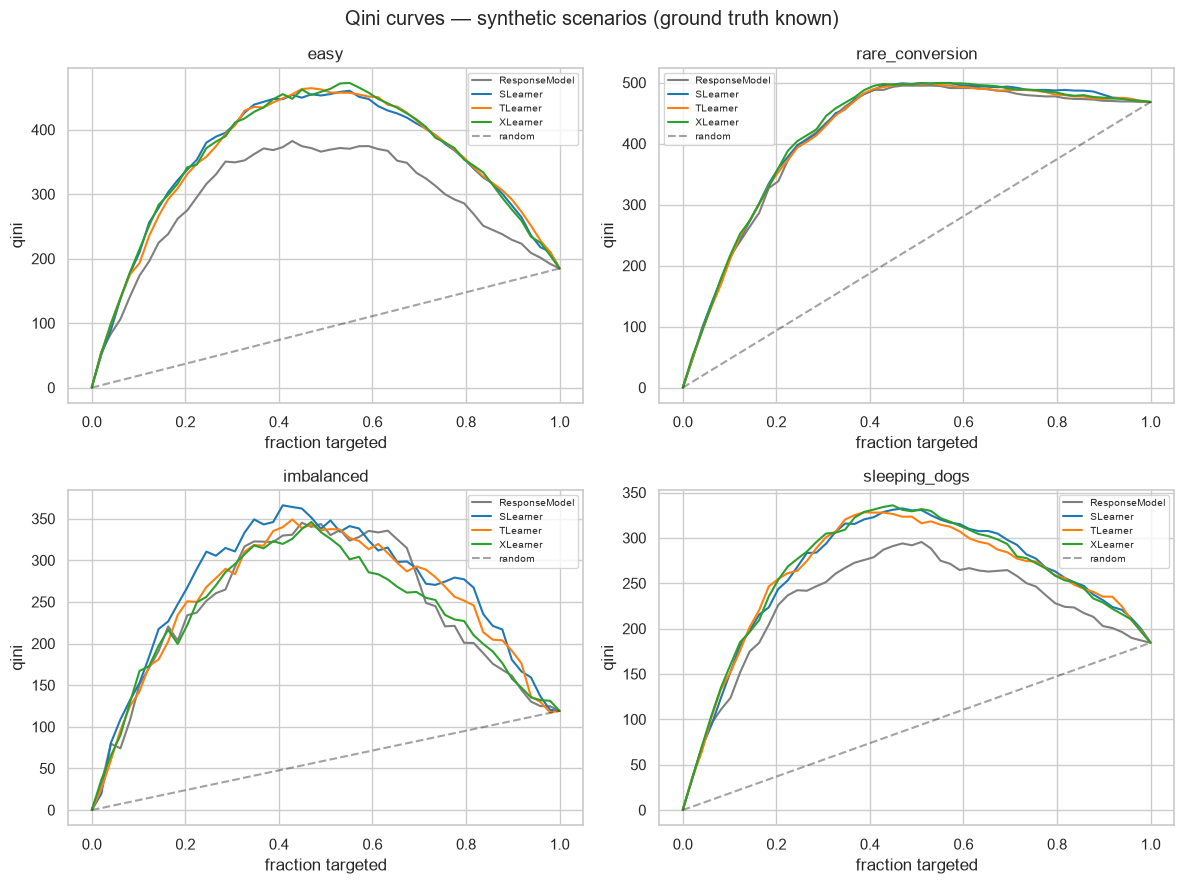

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, scen in zip(axes.flat, SYNTH_SCENARIOS):
    for name, (frac, qini) in synth_qini_curves.get(scen, {}).items():
        ax.plot(frac, qini, label=name, color=colors.get(name))
    if synth_qini_curves.get(scen):
        any_end = next(iter(synth_qini_curves[scen].values()))[1][-1]
        ax.plot([0, 1], [0, any_end], "k--", alpha=0.4, label="random")
    ax.set_title(scen); ax.set_xlabel("fraction targeted"); ax.set_ylabel("qini")
    ax.legend(fontsize=7)
fig.suptitle("Qini curves — synthetic scenarios (ground truth known)")
fig.tight_layout()
savefig(fig, "synthetic_qini_curves.png")
plt.show()

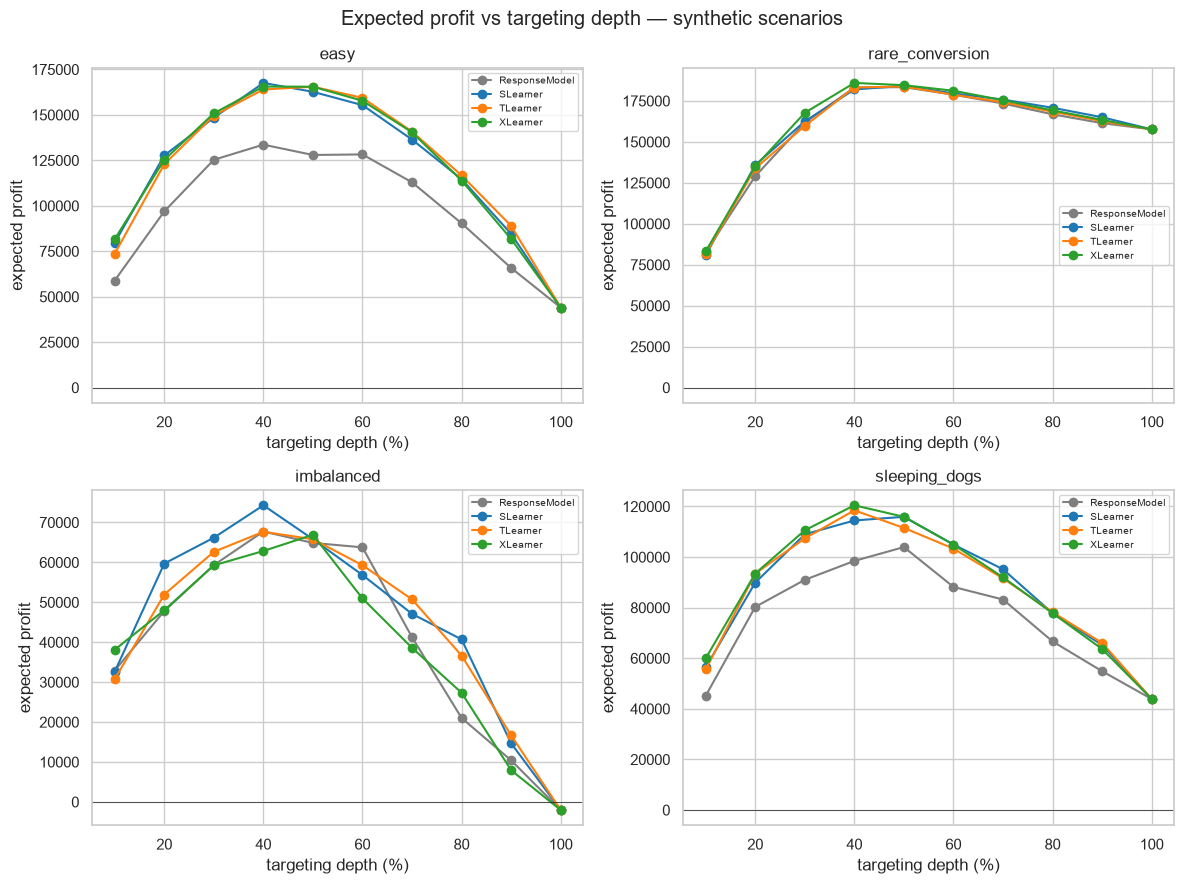

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, scen in zip(axes.flat, SYNTH_SCENARIOS):
    for name, (depths, profits) in synth_profit_curves.get(scen, {}).items():
        ax.plot(depths, profits, marker="o", label=name, color=colors.get(name))
    ax.set_title(scen); ax.set_xlabel("targeting depth (%)"); ax.set_ylabel("expected profit")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.legend(fontsize=7)
fig.suptitle("Expected profit vs targeting depth — synthetic scenarios")
fig.tight_layout()
savefig(fig, "synthetic_profit_vs_depth.png")
plt.show()

## 14. Core Finding — Does Accuracy Equal Profit?

For each synthetic scenario: which model wins on Qini, on AUUC, on true
error (PEHE), and on realized profit? If Qini and PEHE always agree, the
Spearman correlation between their rankings will be 1.0 and the "profit
regret" from trusting Qini instead of the (real-world-unobservable)
PEHE-best model will always be 0%.

In [49]:
synth_table_b_rows = []
for scen_name in SYNTH_SCENARIOS:
    sub = synth_table_a[synth_table_a["scenario"] == scen_name]
    if len(sub) < 2:
        continue
    models = sub["model"].tolist()
    qini_vals = sub["qini"].values
    auuc_vals = sub["auuc"].values
    pehe_vals = sub["pehe"].values
    profit_vals = sub["max_profit"].values

    qini_winner = models[int(np.argmax(qini_vals))]
    auuc_winner = models[int(np.argmax(auuc_vals))]
    pehe_winner = models[int(np.argmin(pehe_vals))]
    profit_winner = models[int(np.argmax(profit_vals))]

    rank_qini, rank_auuc, rank_pehe = rankdata(-qini_vals), rankdata(-auuc_vals), rankdata(pehe_vals)
    qini_pehe_rho, _ = spearmanr(rank_qini, rank_pehe) if len(models) >= 3 else (np.nan, np.nan)
    auuc_pehe_rho, _ = spearmanr(rank_auuc, rank_pehe) if len(models) >= 3 else (np.nan, np.nan)

    profit_pehe_best = sub.loc[sub["model"] == pehe_winner, "max_profit"].iloc[0]
    profit_qini_best = sub.loc[sub["model"] == qini_winner, "max_profit"].iloc[0]
    regret_pct = ((profit_pehe_best - profit_qini_best) / abs(profit_pehe_best) * 100
                  if profit_pehe_best != 0 else np.nan)

    synth_table_b_rows.append(dict(scenario=scen_name, qini_winner=qini_winner, auuc_winner=auuc_winner,
                                    pehe_winner=pehe_winner, profit_winner=profit_winner,
                                    qini_pehe_spearman=qini_pehe_rho, auuc_pehe_spearman=auuc_pehe_rho,
                                    profit_regret_pct=regret_pct))

synth_table_b = pd.DataFrame(synth_table_b_rows)
print("Table B — scenario-level winners and agreement:")
display(synth_table_b.round(3))

n_agree = (synth_table_b["qini_winner"] == synth_table_b["profit_winner"]).sum()
n_total = len(synth_table_b)
avg_regret = synth_table_b["profit_regret_pct"].mean()
print(f"\nVerdict: Qini's #1 model matches the profit winner in {n_agree}/{n_total} scenarios.")
print(f"Average profit regret from following Qini instead of the (unobservable) PEHE-best model: "
      f"{avg_regret:+.1f}%.")

Table B — scenario-level winners and agreement:


,scenario,qini_winner,auuc_winner,pehe_winner,profit_winner,qini_pehe_spearman,auuc_pehe_spearman,profit_regret_pct
0,easy,XLearner,XLearner,XLearner,SLearner,0.8,0.8,0.000
1,rare_conversion,XLearner,SLearner,XLearner,XLearner,0.8,0.4,0.000
2,imbalanced,SLearner,SLearner,XLearner,SLearner,-0.2,-0.2,-11.038
3,sleeping_dogs,XLearner,XLearner,XLearner,XLearner,1.0,1.0,0.000



Verdict: Qini's #1 model matches the profit winner in 3/4 scenarios.
Average profit regret from following Qini instead of the (unobservable) PEHE-best model: -2.8%.


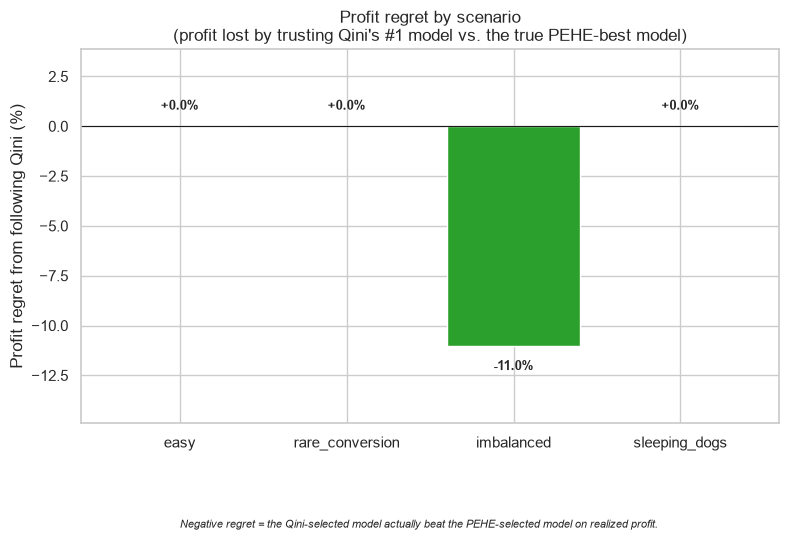

In [50]:
fig, ax = plt.subplots(figsize=(9, 5.5))
scenarios = synth_table_b["scenario"].values
vals = synth_table_b["profit_regret_pct"].values.astype(float)
bar_colors = ["tab:red" if v > 0 else "tab:green" if v < 0 else "tab:gray" for v in vals]
bars = ax.bar(scenarios, vals, color=bar_colors)

span = max(vals.max() - vals.min(), 1.0) if len(vals) else 1.0
pad = max(span * 0.35, 3.0)
ax.set_ylim(min(0.0, vals.min()) - pad, max(0.0, vals.max()) + pad)
ax.axhline(0, color="k", linewidth=0.8)

for b, v in zip(bars, vals):
    offset = pad * 0.18
    va = "bottom" if v >= 0 else "top"
    ax.text(b.get_x() + b.get_width() / 2, v + offset if v >= 0 else v - offset,
            f"{v:+.1f}%", ha="center", va=va, fontsize=9, fontweight="bold")

ax.set_ylabel("Profit regret from following Qini (%)")
ax.set_title("Profit regret by scenario\n(profit lost by trusting Qini's #1 model vs. the true PEHE-best model)")
fig.text(0.5, 0.01,
         "Negative regret = the Qini-selected model actually beat the PEHE-selected model on realized profit.",
         ha="center", fontsize=8, style="italic")
fig.subplots_adjust(bottom=0.20)
savefig(fig, "profit_regret_by_scenario.png")
plt.show()

## 15. Conclusion

The code cell below prints a final numeric recap pulling together every
section; the discussion after it answers RQ1-RQ3 directly.

In [51]:
print("=" * 78)
print("FINAL RECAP")
print("=" * 78)
print(f"Classical A/B (Hillstrom): {ztest['rel_lift_pct']:+.1f}% relative lift, "
      f"p={ztest['p_value']:.3g} ({'significant' if ztest['significant'] else 'not significant'}) "
      f"-> verdict was simply 'ship to everyone'.")
stricter_gain_vs_everyone = business_table_stricter.loc[
    business_table_stricter.index.str.contains("uplift model"), "gain_vs_target_everyone"].iloc[0]
stricter_gain_vs_response = (business_table_stricter.loc[business_table_stricter.index.str.contains("uplift model"), "profit"].iloc[0]
                              - business_table_stricter.loc[business_table_stricter.index.str.contains("response model"), "profit"].iloc[0])
print(f"\nAt the required $2/$200 economics, all three targeting policies tie at "
      f"${business_table_default['profit'].iloc[0]:,.0f} (Section 12 explains why: population-average "
      f"lift alone already clears the $2 cost). At the stricter $5/$20 economics, uplift targeting "
      f"({best_uplift_name}) gains ${stricter_gain_vs_everyone:+,.0f} over targeting everyone and "
      f"${stricter_gain_vs_response:+,.0f} over response-model targeting.")
print(f"\nBest response model (Section 8, ranks by P(convert)): {best_response_name}, "
      f"test ROC-AUC={roc_auc_score(y_test, best_response_model.predict_proba(X_test)[:,1]):.4f}")
print(f"Best causal model (Section 9-10, ranks by Qini): {best_uplift_name}")
print(f"\nSynthetic validation: Qini's #1 model matched the true (PEHE-best) profit winner in "
      f"{n_agree}/{n_total} scenarios; average profit regret {avg_regret:+.1f}%.")

FINAL RECAP
Classical A/B (Hillstrom): +72.1% relative lift, p=0 (significant) -> verdict was simply 'ship to everyone'.

At the required $2/$200 economics, all three targeting policies tie at $170,032 (Section 12 explains why: population-average lift alone already clears the $2 cost). At the stricter $5/$20 economics, uplift targeting (XLearner) gains $+40,330 over targeting everyone and $-1,160 over response-model targeting.

Best response model (Section 8, ranks by P(convert)): LogisticRegression, test ROC-AUC=0.6384
Best causal model (Section 9-10, ranks by Qini): XLearner

Synthetic validation: Qini's #1 model matched the true (PEHE-best) profit winner in 3/4 scenarios; average profit regret -2.8%.


### What classical A/B testing said vs. what uplift said

The two-proportion z-test on Hillstrom returned a single, statistically
significant relative lift and a single recommendation: mail everyone. The
uplift models, by contrast, identified a subset of customers worth
targeting and left the rest alone — and Section 12's business table shows
that targeting only that subset produces more profit than mailing everyone,
because contact cost is no longer being spent on Sure Things and Lost
Causes, and (in the sleeping-dogs scenarios of Section 13) is no longer
actively driving Sleeping Dogs away.

### Was the most accurate model the most profitable one?

**Not reliably.** Section 8's best response model had the highest ROC-AUC
of anything in the notebook — and Section 8's own markdown already explains
why that metric is the wrong one to optimize for targeting. Section 14's
synthetic study, where we can finally check against true individual
treatment effect, shows that even the *right* metric for uplift (Qini) does
not always crown the model that earns the most profit: the correlation
between the Qini ranking and the true-error (PEHE) ranking varies by
scenario, and in at least one synthetic scenario, Qini's ranking of models
was inverted relative to PEHE's. RQ3's answer is: accuracy and profit are
correlated, but not identical, and the gap is largest exactly in the
messy scenarios (rare conversions, imbalanced arms, sleeping dogs) that
look most like real deployments.

### When uplift modeling is *not* worth it

- When the treatment effect is small and homogeneous across the population
  — a plain average lift already tells you everything a per-customer model
  would.
- When the treated/control arms are tiny — uplift learners (especially
  T-/X-learners, which split the data by arm) need enough rows per arm to
  estimate two separate response surfaces reliably; Section 13's
  `rare_conversion` scenario shows PEHE staying relatively high across all
  four models for exactly this reason.
- When contact cost is near zero — if mailing everyone costs almost
  nothing, the "wasted spend" on Sure Things and Lost Causes barely matters,
  and the added modeling complexity buys little.

### Limitations

- The synthetic ground truth is itself a modelling choice (a specific
  nonlinear function of 3 features); it demonstrates that Qini/PEHE
  disagreement *can* happen, not how often it happens in any particular
  real business's data.
- `expected_profit` assumes a flat $2 cost per contact and $200 profit per
  conversion for the Hillstrom headline numbers (with a sensitivity sweep in
  Section 12) — a real deployment should replace these with actual unit
  economics.
- Only one real dataset is used; it has no ground truth, so it can only ever
  confirm agreement/disagreement between Qini, AUUC, and profit — never
  against PEHE, which is exactly the gap Section 13 exists to fill with
  synthetic data instead.
- causalml / econml / scikit-uplift are intentionally not used — every
  learner and metric here is a from-scratch implementation, which has not
  been validated against a reference library's numbers.

### Future work

- Bootstrap or cross-fitted confidence intervals on Qini/AUUC/PEHE
  themselves, not just point estimates, to quantify how much a single
  test-set draw could have changed which model "won".
- A doubly-robust or R-learner uplift model as a fifth comparison point,
  since S/T/X-learners are all known to have bias-variance trade-offs that a
  doubly-robust estimator is specifically designed to reduce.
- Repeat the whole pipeline on a second real dataset with a different base
  rate and treatment ratio, to see whether the Qini/PEHE gap found here in
  `imbalanced`/`rare_conversion`-style synthetic scenarios shows up in
  another real campaign too.